In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('jd dataset.csv')

In [3]:
df.head()

,job_id,job_title,company,location,job_description,experience,education,salary_lpa,job_type,required_skills
0,JOB103863,Business Analyst,Deloitte,"Chennai, Tamil Nadu",We are hiring a Business Analyst at Deloitte i...,1-3 years,Be Computer Engineering,5.5,Contract,"SQL, JIRA, Power BI, Statistics"
1,JOB154438,Business Analyst,Persistent Systems,NaN,We are hiring a Business Analyst at Persistent...,5-8 years,MCA,8.5,Internship,"Tableau, Power BI, Excel, Statistics, SQL"
2,JOB259541,Machine Learning Engineer,Deloitte,"Nagpur, Maharashtra",We are hiring a Machine Learning Engineer at D...,8-12 years,MBA,13.0,Part-time,"Python, Scikit-learn, TensorFlow, Machine Lear..."
3,JOB134355,Python Developer,Wipro,"Remote, India",We are hiring a Python Developer at Wipro in R...,1-3 years,MSc Data Science,5.7,Full-time,"Python, REST API, Git, Docker, FastAPI, Django"
4,JOB154998,Software Engineer,Capgemini,"Bengaluru, Karnataka",We are hiring a Software Engineer at Capgemini...,2-5 years,NaN,5.0 LPA,Contract,C++ | Docker | REST API | SQL | Agile | Java


In [4]:
df.tail()

,job_id,job_title,company,location,job_description,experience,education,salary_lpa,job_type,required_skills
4313,JOB135886,Python Developer,HCLTech,NaN,We are hiring a Python Developer at HCLTech in...,5-8 years,BCA,9.5,Part-time,"SQL, REST API, Flask, Git, Django, Python, Fas..."
4314,JOB239434,Data Engineer,Accenture,"Nagpur, Maharashtra",We are hiring a Data Engineer at Accenture in...,3-6 years,BCA,6.9,Internship,"SQL, AWS, Python, Spark, Airflow, ETL, Azure, ..."
4315,JOB269946,Python Developer,HCLTech,"Ahmedabad, Gujarat",We are hiring a Python Developer at HCLTech in...,2-5 years,MSc Data Science,7.0,Contract,"Python, Docker, REST API, FastAPI"
4316,JOB056191,AI Engineer,Zoho,"Nashik, Maharashtra","We are hiring a AI Engineer at Zoho in Nashik,...",2-5 years,BCA,7.3,Part-time,"Python, Deep Learning, Docker, Machine Learnin..."
4317,JOB172003,DEVOPS ENGINEER,HCLTech,"Remote, India",We are hiring a DevOps Engineer at HCLTech in...,5-8 years,Any Graduate,9,Part-time,"Terraform, CI/CD, Docker, Git, Jenkins, Linux,..."


In [5]:
df.sample(8)

,job_id,job_title,company,location,job_description,experience,education,salary_lpa,job_type,required_skills
1615,JOB255387,Software Engineer,IBM,"Bengaluru, Karnataka",We are hiring a Software Engineer at IBM in Be...,8-12 years,MBA,13.1,Part-Time,"Python, C++, REST API, Java, Docker, Agile, Git"
3219,JOB033467,DEVOPS ENGINEER,IBM,"Gurugram, Haryana",We are hiring a DevOps Engineer at IBM in Guru...,5-8 years,MCA,10.4,Internship,"Terraform,Git,Jenkins,CI/CD,Kubernetes,Docker,..."
1270,JOB219216,Business Analyst,Cognida,"Gurugram, Haryana",We are hiring a Business Analyst at Cognida i...,2-5 years,MCA,4.8,Full-time,"Power BI, JIRA, Business Analysis, Excel, Stat..."
803,JOB037039,Software Engineer,LTIMindtree,"Ahmedabad, Gujarat",We are hiring a Software Engineer at LTIMindtr...,2-5 years,BE Computer Engineering,5.4,Full-time,"REST API, Python, C++, Docker, SQL, Java, Git,..."
4115,JOB041611,Software Engineer,Mphasis,"Noida, Uttar Pradesh",We are hiring a Software Engineer at Mphasis i...,5-8 years,MBA,8.3,Full-Time,"Git, Python, Java, REST API, Agile"
2106,JOB204814,Python Developer,Cognizant,NaN,We are hiring a Python Developer at Cognizant ...,1-3 years,Bsc Computer Science,6.0,Full-time,"REST API, Django, Docker, SQL, Flask, Python, ..."
1448,JOB288553,Business Analyst,Zoho,"Pune, Maharashtra",We are hiring a Business Analyst at Zoho in P...,0-1 years,BTech Computer Science,3.5,Contract,"Power BI, Tableau, Excel, Business Analysis, S..."
580,JOB248818,Java Developer,Tech Mahindra,"Hyderabad, Telangana",We are hiring a Java Developer at Tech Mahindr...,1-3 years,BSc Data Science,4.6,Internship,"Hibernate, REST API, Docker, Spring Boot, Micr..."


In [6]:
df.shape

(4318, 10)

In [7]:
df.columns

Index(['job_id', 'job_title', 'company', 'location', 'job_description',
       'experience', 'education', 'salary_lpa', 'job_type', 'required_skills'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4318 entries, 0 to 4317
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           4318 non-null   object
 1   job_title        4318 non-null   object
 2   company          4318 non-null   object
 3   location         4146 non-null   object
 4   job_description  4318 non-null   object
 5   experience       4177 non-null   object
 6   education        4169 non-null   object
 7   salary_lpa       4172 non-null   object
 8   job_type         4318 non-null   object
 9   required_skills  4220 non-null   object
dtypes: object(10)
memory usage: 337.5+ KB


In [9]:
df["salary_lpa"] = (
    df["salary_lpa"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace("LPA", "", case=False, regex=False)
    .str.strip())

df["salary_lpa"] = pd.to_numeric(df["salary_lpa"], errors="coerce")

In [10]:
df['salary_lpa'].dtype

dtype('float64')

In [11]:
df.sample(10)

,job_id,job_title,company,location,job_description,experience,education,salary_lpa,job_type,required_skills
691,JOB297832,Cloud Engineer,Microsoft,"Nagpur, Maharashtra",We are hiring a Cloud Engineer at Microsoft in...,1-3 years,Any Graduate,4.0,Internship,"CI/CD, Azure, Git, Kubernetes"
1874,JOB005580,Power BI Developer,Wipro,"Nashik, Maharashtra",We are hiring a Power BI Developer at Wipro in...,0-1 years,BCA,3.3,Part-time,"Data Modeling, SQL, ETL, DAX, Power BI, Excel,..."
3651,JOB182628,Data Scientist,cognizant,"Gurugram, Haryana",We are hiring a Data Scientist at Cognizant in...,8-12 years,NaN,13.9,INTERNSHIP,"Scikit-learn, TensorFlow, Machine Learning, SQ..."
3542,JOB115318,Web Developer,Amazon,"Remote, India",We are hiring a Web Developer at Amazon in Rem...,0-1 years,BTech Computer Science,3.5,Internship,"CSS,JavaScript,HTML,Node.js,React,MongoDB,REST..."
3029,JOB196021,AI Engineer,Infosys,"Noida, Uttar Pradesh",We are hiring a AI Engineer at Infosys in Noid...,8-12 years,BSc Computer Science,12.0,Internship,"tensorflow,pytorch,machine learning,llm,docker..."
52,JOB098519,Python Developer,Fractal Analytics,"Bengaluru, Karnataka",We are hiring a Python Developer at Fractal An...,0-1 years,BTech Computer Science,4.1,Internship,"FastAPI, Python, Git, Django"
2604,JOB040092,SQL Developer,ORACLE,"Delhi, India",We are hiring a SQL Developer at Oracle in Del...,2-5 years,MBA,6.6,Full-time,"PostgreSQL, Python, SQL, ETL, Database Design"
1571,JOB214028,DevOps Engineer,infosys,"Ahmedabad, Gujarat",We are hiring a DevOps Engineer at Infosys in ...,5-8 years,BCA,8.3,Internship,"AWS, CI/CD, Kubernetes, Terraform, Linux, Jenk..."
3725,JOB150193,Machine Learning Engineer,TECH MAHINDRA,"Ahmedabad, Gujarat",We are hiring a Machine Learning Engineer at T...,1-3 years,MBA,4.0,Contract,"Python, Docker, AWS, SQL, Scikit-learn"
1255,JOB290993,Web Developer,Siemens,"Pune, Maharashtra",We are hiring a Web Developer at Siemens in Pu...,3-6 years,MBA,7.0,FULL TIME,"HTML, React, REST API, JavaScript, Git"


In [12]:
df.isnull().sum()

job_id               0
job_title            0
company              0
location           172
job_description      0
experience         141
education          149
salary_lpa         146
job_type             0
required_skills     98
dtype: int64

In [13]:
missing_per = (df.isnull().sum() / len(df)) * 100
missing_per

job_id             0.000000
job_title          0.000000
company            0.000000
location           3.983326
job_description    0.000000
experience         3.265401
education          3.450672
salary_lpa         3.381195
job_type           0.000000
required_skills    2.269569
dtype: float64

In [14]:
df.duplicated().sum()

np.int64(20)

In [15]:
df[df.duplicated()]

,job_id,job_title,company,location,job_description,experience,education,salary_lpa,job_type,required_skills
541,JOB282810,Power BI Developer,mphasis,"Gurugram, Haryana",We are hiring a Power BI Developer at Mphasis ...,3-6 years,BTech Computer Science,7.7,Full-time,"Power Query, DAX, ETL, Data Modeling, Excel, P..."
793,JOB265896,Power BI Developer,Fractal Analytics,"Chennai, Tamil Nadu",We are hiring a Power BI Developer at Fractal ...,3-6 years,MBA,6.7,Part-time,"Data Modeling, Excel, SQL, DAX, Power Query, ETL"
949,JOB060827,Data Engineer,Infosys,"Nagpur, Maharashtra",We are hiring a Data Engineer at Infosys in Na...,8-12 years,MSc Data Science,12.6,Full-time,"SQL, Airflow, ETL, Spark, Python, AWS, Azure, ..."
1238,JOB074285,Web Developer,Zoho,"Chennai, Tamil Nadu",We are hiring a Web Developer at Zoho in Chenn...,5-8 years,BCA,10.0,Internship,"Node.js, HTML, REST API, JavaScript, MongoDB, ..."
1511,JOB139250,SQL Developer,HCLTech,"Pune, Maharashtra",We are hiring a SQL Developer at HCLTech in P...,5-8 years,BSc Computer Science,10.2,Full-time,"MySQL, PostgreSQL, SQL Server, Database Design..."
1626,JOB132073,Java Developer,Cognizant,"Delhi, India",We are hiring a Java Developer at Cognizant in...,1-3 years,BTech Computer Science,5.1,Contract,"Java, Microservices, Spring Boot, SQL, Git, Do..."
1817,JOB078082,DevOps Engineer,Deloitte,"Chennai, Tamil Nadu",We are hiring a DevOps Engineer at Deloitte in...,8-12 years,BCA,12.6,Contract,"CI/CD, Git, Docker, Jenkins"
1845,JOB116597,SQL Developer,Wipro,"gurugram, haryana",We are hiring a SQL Developer at Wipro in Guru...,3-6 years,BSc Computer Science,7.9,Part-time,"SQL, ETL, MySQL, Python"
2293,JOB137673,Data Analyst,Cognizant,"Nashik, Maharashtra",We are hiring a Data Analyst at Cognizant in N...,2-5 years,MBA,6.1,PART-TIME,"Excel, SQL, Python, Statistics, Pandas, Power ..."
2325,JOB136327,Data Analyst,Infosys,"Pune, Maharashtra",We are hiring a Data Analyst at Infosys in Pun...,NaN,BE Computer Engineering,4.9,Part-time,"Statistics, Tableau, Pandas, SQL, NumPy"


In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.isnull().sum()

job_id               0
job_title            0
company              0
location           172
job_description      0
experience         140
education          149
salary_lpa         146
job_type             0
required_skills     98
dtype: int64

In [19]:
df['location'] = df['location'].fillna('Unknown')

In [20]:
df['education'] = df['education'].fillna('Not Specified')

In [21]:
df['salary_lpa'] = df['salary_lpa'].fillna(df['salary_lpa'].median())

In [22]:
df.isnull().sum()

job_id               0
job_title            0
company              0
location             0
job_description      0
experience         140
education            0
salary_lpa           0
job_type             0
required_skills     98
dtype: int64

In [23]:
df.shape

(4298, 10)

In [24]:
df['experience'].unique()

array(['1-3 years', '5-8 years', '8-12 years', '2-5 years', '8-12 years ',
       '3-6 years', ' 5-8 years ', '3-6 years ', '0-1 years', nan,
       '5-8 years ', ' 1-3 years ', '0-1 years ', ' 0-1 years ',
       ' 8-12 years', ' 5-8 years', '1-3 years ', ' 2-5 years ',
       ' 3-6 years ', '2-5 years ', ' 1-3 years', ' 0-1 years',
       ' 3-6 years', ' 8-12 years ', ' 2-5 years'], dtype=object)

In [25]:
df['experience'] = (
    df['experience']
    .astype(str)
    .str.replace("years", "", case=False, regex=False) 
    .str.strip())

In [26]:
df['experience'].unique()

array(['1-3', '5-8', '8-12', '2-5', '3-6', '0-1', 'nan'], dtype=object)

In [27]:
df["experience"] = df["experience"].replace("nan", np.nan)

In [28]:
df["experience_avg"] = df["experience"].apply(
    lambda x: (float(x.split("-")[0]) + float(x.split("-")[1])) / 2
    if pd.notna(x) else np.nan
)

In [29]:
avg_experience = round(df["experience_avg"].mean(),1)

print(avg_experience)

4.6


In [30]:
df["experience_avg"] = df["experience_avg"].fillna(avg_experience)

In [31]:
df.sample(10)

,job_id,job_title,company,location,job_description,experience,education,salary_lpa,job_type,required_skills,experience_avg
963,JOB021040,DevOps Engineer,Deloitte,"DELHI, INDIA",We are hiring a DevOps Engineer at Deloitte in...,0-1,Any Graduate,3.2,Contract,"Linux, Kubernetes, Docker, Git, CI/CD, AWS, Je...",0.5
3706,JOB084766,Cloud Engineer,Microsoft,"Delhi, India",We are hiring a Cloud Engineer at Microsoft in...,NaN,BTech Computer Science,5.0,Part-time,"Docker, Azure, Git, Kubernetes, CI/CD, Linux",4.6
1801,JOB032634,SQL Developer,Walmart Global Tech,"Gurugram, Haryana",We are hiring a SQL Developer at Walmart Globa...,5-8,BSc Computer Science,9.6,Full-time,"SQL, MySQL, SQL Server, PostgreSQL",6.5
2509,JOB158120,Machine Learning Engineer,Microsoft,"Noida, Uttar Pradesh",We are hiring a Machine Learning Engineer at M...,0-1,Any Graduate,3.0,Full-time,"SQL, TensorFlow, Docker, Scikit-learn",0.5
1525,JOB020788,Data Analyst,BOSCH,"Nagpur, Maharashtra",We are hiring a Data Analyst at Bosch in Nagpu...,3-6,MCA,6.0,Part-time,"SQL, Power BI, Pandas, Tableau, NumPy, Python,...",4.5
3376,JOB138316,Software Engineer,Zoho,"Hyderabad, Telangana",We are hiring a Software Engineer at Zoho in ...,8-12,BSc Data Science,13.3,Part-time,"Python, Agile, C++, Docker, Git, Java",10.0
4274,JOB216081,Data Engineer,Fractal Analytics,"Chennai, Tamil Nadu",We are hiring a Data Engineer at Fractal Analy...,1-3,MSc Data Science,5.9,Part-time,"Python, AWS, Airflow, Spark, ETL",2.0
2344,JOB293399,Java Developer,Infosys,"Gurugram, Haryana",We are hiring a Java Developer at Infosys in G...,2-5,BE Computer Engineering,4.9,Internship,"Java, Microservices, Spring Boot, SQL, Docker",3.5
389,JOB026192,Data Scientist,TCS,"REMOTE, INDIA",We are hiring a Data Scientist at TCS in Remot...,2-5,BTech Computer Science,6.3,Contract,"Statistics, Python, NumPy, SQL, Pandas, Tensor...",3.5
853,JOB219890,Java Developer,MICROSOFT,"Ahmedabad, Gujarat",We are hiring a Java Developer at Microsoft in...,3-6,BTech Computer Science,7.7,Full-time,"Git, SQL, Docker, REST API, Hibernate, Java, M...",4.5


In [32]:
df.isnull().sum()

job_id               0
job_title            0
company              0
location             0
job_description      0
experience         140
education            0
salary_lpa           0
job_type             0
required_skills     98
experience_avg       0
dtype: int64

In [33]:
df[df["experience"].isna()]

,job_id,job_title,company,location,job_description,experience,education,salary_lpa,job_type,required_skills,experience_avg
37,JOB007629,Sql Developer,Amazon,"Nashik, Maharashtra",We are hiring a SQL Developer at Amazon in Nas...,NaN,BSc Computer Science,13.5,Internship,"SQL Server, Python, SQL, Database Design, ETL,...",4.6
65,JOB076910,Web Developer,Wipro,"Hyderabad, Telangana",We are hiring a Web Developer at Wipro in Hyde...,NaN,BTech Computer Science,10.4,Contract,"Git, REST API, React, HTML, JavaScript, CSS, M...",4.6
154,JOB281207,Software Engineer,TCS,"Nagpur, Maharashtra",We are hiring a Software Engineer at TCS in Na...,NaN,MBA,6.2,Contract,"Docker, REST API, SQL, Git, C++",4.6
167,JOB093014,Data Engineer,IBM,"Ahmedabad, Gujarat",We are hiring a Data Engineer at IBM in Ahmed...,NaN,BTech Computer Science,5.1,Contract,"SQL, AWS, Azure, Databricks, Airflow, ETL, Spa...",4.6
169,JOB278081,Business Analyst,HCLTech,Unknown,We are hiring a Business Analyst at HCLTech in...,NaN,BSc Data Science,12.5,Part-time,"Business Analysis, JIRA, SQL, Statistics",4.6
...,...,...,...,...,...,...,...,...,...,...,...
4152,JOB275623,Data Scientist,tech mahindra,"Chennai, Tamil Nadu",We are hiring a Data Scientist at Tech Mahindr...,NaN,BCA,11.9,part-time,"Statistics, NumPy, TensorFlow, Machine Learnin...",4.6
4221,JOB275669,Power Bi Developer,Capgemini,"Chennai, Tamil Nadu",We are hiring a Power BI Developer at Capgemin...,NaN,BTech Computer Science,2.8,Contract,Excel | Power BI | Data Modeling | ETL | DAX,4.6
4268,JOB290798,Data Engineer,Bosch,"Ahmedabad, Gujarat",We are hiring a Data Engineer at Bosch in Ahme...,NaN,BE Computer Engineering,3.5,Internship,"ETL, SQL, Airflow, Azure, Python, Databricks, ...",4.6
4283,JOB180363,SQL Developer,Fractal Analytics,"GURUGRAM, HARYANA",We are hiring a SQL Developer at Fractal Analy...,NaN,MBA,13.4,Part-time,"SQL, ETL, MySQL, Python, SQL Server",4.6


In [34]:
df = df.dropna(subset=['required_skills']).reset_index(drop=True)

In [35]:
df['experience'] = df['experience'].fillna(round(df['experience_avg'].mean(),1))

In [36]:
df.iloc[[37,65]]

,job_id,job_title,company,location,job_description,experience,education,salary_lpa,job_type,required_skills,experience_avg
37,JOB007629,Sql Developer,Amazon,"Nashik, Maharashtra",We are hiring a SQL Developer at Amazon in Nas...,4.6,BSc Computer Science,13.5,Internship,"SQL Server, Python, SQL, Database Design, ETL,...",4.6
65,JOB024784,Power BI Developer,HCLTech,"Noida, Uttar Pradesh",We are hiring a Power BI Developer at HCLTech ...,2-5,MBA,6.7,Part-time,"Data Modeling, Excel, SQL, ETL",3.5


In [37]:
df.isnull().sum()

job_id             0
job_title          0
company            0
location           0
job_description    0
experience         0
education          0
salary_lpa         0
job_type           0
required_skills    0
experience_avg     0
dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_id           4200 non-null   object 
 1   job_title        4200 non-null   object 
 2   company          4200 non-null   object 
 3   location         4200 non-null   object 
 4   job_description  4200 non-null   object 
 5   experience       4200 non-null   object 
 6   education        4200 non-null   object 
 7   salary_lpa       4200 non-null   float64
 8   job_type         4200 non-null   object 
 9   required_skills  4200 non-null   object 
 10  experience_avg   4200 non-null   float64
dtypes: float64(2), object(9)
memory usage: 361.1+ KB


# EDA

In [39]:
no_job = df['job_id'].count()
print('Number Of Jobs :',no_job)

Number Of Jobs : 4200


In [40]:
n_unique_job_t = df['job_title'].nunique()
print('Number of unique job titles :',n_unique_job_t)

Number of unique job titles : 123


In [41]:
df['job_title'].value_counts().head(10)

job_title
Software Engineer            263
Cloud Engineer               253
Data Scientist               249
Machine Learning Engineer    244
Web Developer                243
AI Engineer                  240
SQL Developer                234
Data Engineer                232
Data Analyst                 232
Business Analyst             226
Name: count, dtype: int64

In [42]:
job_by_location = df['location'].value_counts()
job_by_location.head(10)

location
Hyderabad, Telangana    303
Remote, India           300
Ahmedabad, Gujarat      300
Nashik, Maharashtra     297
Noida, Uttar Pradesh    286
Delhi, India            286
Chennai, Tamil Nadu     284
Nagpur, Maharashtra     275
Mumbai, Maharashtra     274
Gurugram, Haryana       268
Name: count, dtype: int64

In [43]:
df['description_length'] = df['job_description'].str.len()

In [44]:
avg_desc_len =df['description_length'].mean()
print('Average Description Length :',avg_desc_len)

Average Description Length : 561.6719047619048


In [45]:
min_desc_len = df['description_length'].min()
print('Minimum Description Length :',min_desc_len)

Minimum Description Length : 475


In [46]:
max_desc_len = df['description_length'].max()
print('Maximum Description Length :',max_desc_len)

Maximum Description Length : 707


In [47]:
df['description_length'].describe()

count    4200.000000
mean      561.671905
std        32.540783
min       475.000000
25%       538.000000
50%       559.000000
75%       583.000000
max       707.000000
Name: description_length, dtype: float64

In [48]:
df.isnull().sum()

job_id                0
job_title             0
company               0
location              0
job_description       0
experience            0
education             0
salary_lpa            0
job_type              0
required_skills       0
experience_avg        0
description_length    0
dtype: int64

In [49]:
unique_companies = df['company'].nunique()
print("Unique Companies:", unique_companies)

Unique Companies: 165


In [50]:
unique_locations = df['location'].nunique()
print("Unique Locations:", unique_locations)

Unique Locations: 88


In [51]:
avg_salary = df['salary_lpa'].mean()
print("Average Salary in LPA:", round(avg_salary,2))

Average Salary in LPA: 8.87


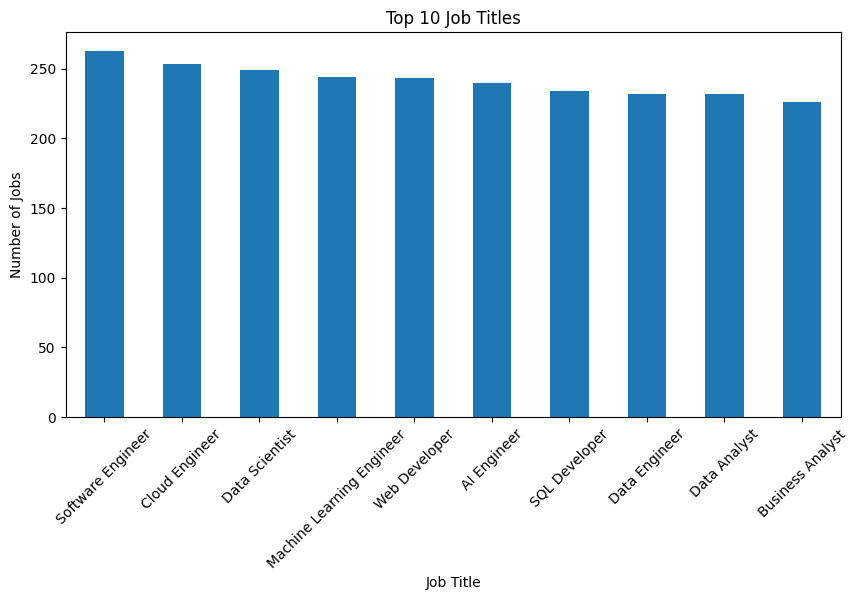

In [52]:
plt.figure(figsize=(10, 5))
df['job_title'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)

plt.show()

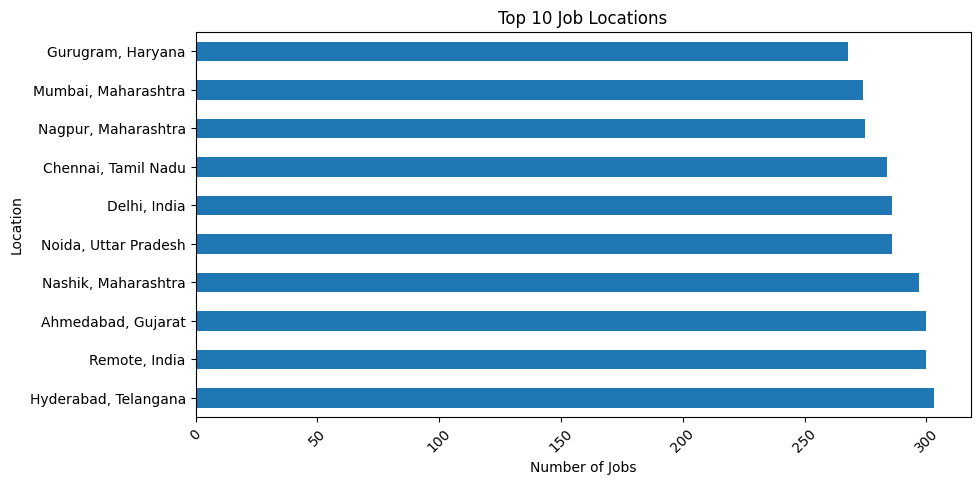

In [53]:
plt.figure(figsize=(10, 5))
df['location'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Job Locations')
plt.ylabel('Location')
plt.xlabel('Number of Jobs')
plt.xticks(rotation=45)
plt.show()

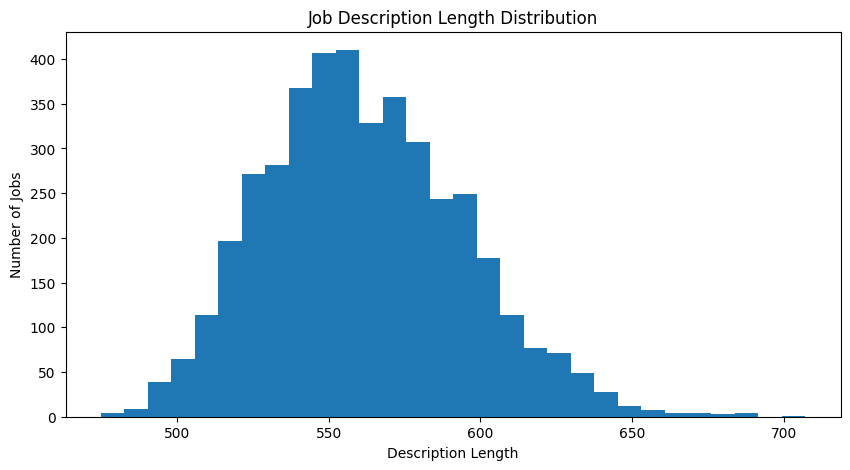

In [54]:
plt.figure(figsize=(10, 5))
plt.hist(df['description_length'], bins=30)
plt.title('Job Description Length Distribution')
plt.xlabel('Description Length')
plt.ylabel('Number of Jobs')
plt.show()

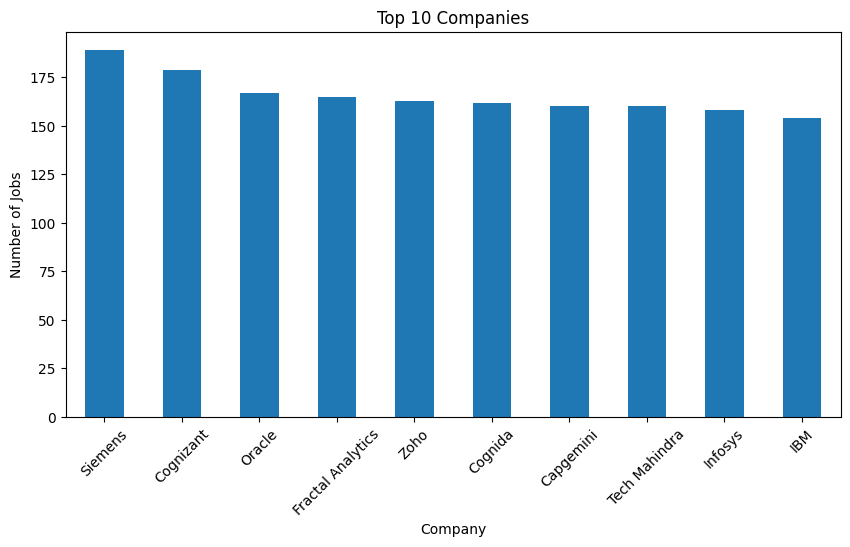

In [55]:
plt.figure(figsize=(10, 5))
df['company'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Companies')
plt.xlabel('Company')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.show()

In [56]:
top_5_education = df['education'].value_counts().head(5)
print(top_5_education)

education
BTech Computer Science    387
BSc Data Science          387
Any Graduate              381
BCA                       380
MBA                       380
Name: count, dtype: int64


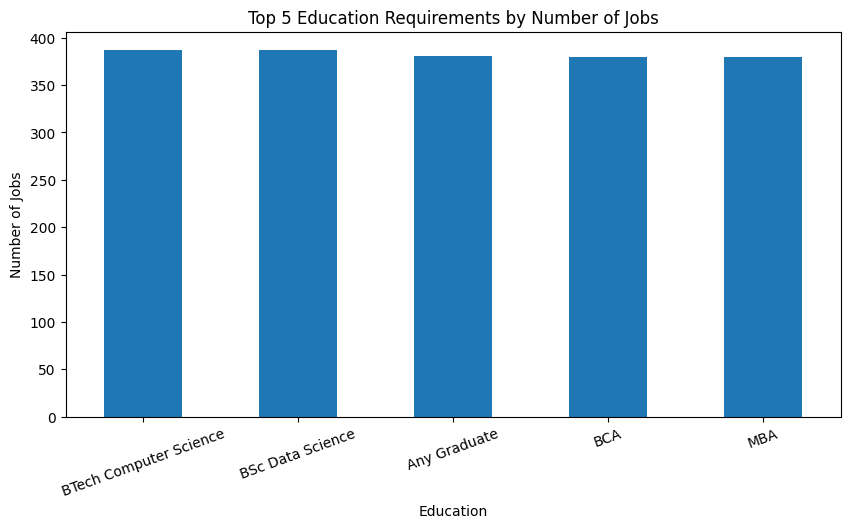

In [57]:
plt.figure(figsize=(10, 5))
top_5_education.plot(kind='bar')
plt.title('Top 5 Education Requirements by Number of Jobs')
plt.xlabel('Education')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=20)
plt.show()

In [58]:
top_skills = df['required_skills'].value_counts()
top_skills.head(5)

required_skills
SQL, MySQL, SQL Server, PostgreSQL                                    2
Hibernate, REST API, Microservices, Java                              2
MySQL, PostgreSQL, Python, SQL                                        2
TensorFlow, PyTorch, Docker, NLP, Deep Learning, Python, LLM          2
SQL, JIRA, Excel, Statistics, Tableau, Business Analysis, Power BI    2
Name: count, dtype: int64

In [59]:
import re 
def clean_text(text): 
    text = str(text)
    text = re.sub(r"http\S+", "", text) 
    text = re.sub(r"<.*?>", "", text) 
    text = re.sub(r"\S+@\S+", "", text) 
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text) 
    text = re.sub(r"\s+", " ", text) 
    return text.strip().lower()

In [60]:
df['job_description'].head()

0    We are hiring a Business Analyst at Deloitte i...
1    We are hiring a Business Analyst at Persistent...
2    We are hiring a Machine Learning Engineer at D...
3    We are hiring a Python Developer at Wipro in R...
4    We are hiring a Software Engineer at Capgemini...
Name: job_description, dtype: object

In [61]:
df['clean_description'] = df['job_description'].apply(clean_text)

In [62]:
df['clean_description'].head()

0    we are hiring a business analyst at deloitte i...
1    we are hiring a business analyst at persistent...
2    we are hiring a machine learning engineer at d...
3    we are hiring a python developer at wipro in r...
4    we are hiring a software engineer at capgemini...
Name: clean_description, dtype: object

In [63]:
print(df.iloc[2]['job_description'])

We are hiring a Machine Learning Engineer at Deloitte in Nagpur, Maharashtra. The role requires 8-12 years of experience and MBA or a related qualification. The candidate will develop and maintain solutions related to machine learning engineer, and work on projects involving TensorFlow, Scikit-learn, Machine Learning, AWS, Python, SQL. Key responsibilities include write documentation and perform testing, solving technical problems, improving performance, and communicating results. Experience with TensorFlow, Scikit-learn, Machine Learning, AWS, Python, SQL is preferred. This is a part-time opportunity.


In [64]:
print(df.iloc[5]['job_description'])

We are hiring a Business Analyst at Persistent Systems in Bengaluru, Karnataka. The role requires 8-12 years of experience and BCA or a related qualification. The candidate will develop and maintain solutions related to business analyst, and work on projects involving Statistics, Tableau, SQL, Power BI, Excel, JIRA. Key responsibilities include analyze business requirements and convert them into technical solutions, solving technical problems, improving performance, and communicating results. Experience with Statistics, Tableau, SQL, Power BI, Excel, JIRA is preferred. This is a full-time opportunity.


In [65]:
print(df.iloc[2]['clean_description'])

we are hiring a machine learning engineer at deloitte in nagpur maharashtra the role requires 8 12 years of experience and mba or a related qualification the candidate will develop and maintain solutions related to machine learning engineer and work on projects involving tensorflow scikit learn machine learning aws python sql key responsibilities include write documentation and perform testing solving technical problems improving performance and communicating results experience with tensorflow scikit learn machine learning aws python sql is preferred this is a part time opportunity


In [66]:
df.shape

(4200, 13)

### Skill Taxonomy

In [67]:
skill_taxonomy = {
    "Programming": [
        "Python", "Java", "C", "C++", "C#", "JavaScript",
        "TypeScript", "R", "Go", "Rust", "PHP", "Ruby",
        "Kotlin", "Swift", "Scala", "MATLAB"],
    "Database": [
        "SQL", "MySQL", "PostgreSQL", "Oracle", "SQL Server",
        "SQLite", "MongoDB", "Cassandra", "Redis", "Firebase",
        "DynamoDB", "MariaDB", "Neo4j"],
    "Data Analytics": [
        "Pandas", "NumPy", "Excel", "Power BI", "Tableau",
        "Qlik Sense", "Looker", "Looker Studio", "Plotly",
        "Matplotlib", "Seaborn"],
    "Machine Learning": [
        "Scikit-learn", "XGBoost", "LightGBM", "CatBoost",
        "Random Forest", "Linear Regression", "Logistic Regression",
        "Decision Tree", "KNN", "SVM", "Naive Bayes",
        "Clustering", "K-Means", "PCA"],
    "Deep Learning": [
        "TensorFlow", "PyTorch", "Keras", "OpenCV",
        "CNN", "RNN", "LSTM", "GRU", "GAN", "Transformer"],
    "NLP": [
        "NLTK", "spaCy", "Hugging Face", "Transformers",
        "BERT", "RoBERTa", "GPT", "Word2Vec", "GloVe",
        "FastText", "Text Classification",
        "Named Entity Recognition", "Sentiment Analysis",
        "Text Summarization", "Tokenization", "TF-IDF"],
    "Cloud": [
        "AWS", "Azure", "GCP", "Amazon EC2", "Amazon S3",
        "AWS Lambda", "AWS Glue", "AWS RDS",
        "Azure Data Factory", "Azure Blob Storage",
        "Azure Synapse", "Google BigQuery",
        "Google Cloud Storage", "Google Cloud Functions"],
    "Big Data": [
        "Spark", "PySpark", "Hadoop", "Hive", "Kafka",
        "Flink", "Databricks", "HBase", "Sqoop"],
    "DevOps": [
        "Docker", "Kubernetes", "Jenkins", "Git", "GitHub",
        "GitLab", "Bitbucket", "CI/CD", "Terraform",
        "Ansible", "Docker Compose"],
    "Web Development": [
        "HTML", "CSS", "React", "Angular", "Vue.js",
        "Node.js", "Express.js", "Flask", "Django",
        "FastAPI", "REST API"],
    "Data Engineering": [
        "Apache Airflow", "ETL", "ELT", "Data Pipeline",
        "Data Warehouse", "Snowflake", "Redshift",
        "Azure Data Factory", "AWS Glue",
        "Databricks", "BigQuery", "Azure Synapse"],
    "Generative AI": [
        "Generative AI", "Large Language Models", "LLM",
        "LangChain", "LlamaIndex", "OpenAI API", "RAG",
        "Vector Database", "FAISS", "ChromaDB",
        "Pinecone", "Prompt Engineering", "Embeddings",
        "Sentence Transformers"]}

In [68]:
len(skill_taxonomy)

12

In [69]:
skill_taxonomy["Programming"]

['Python',
 'Java',
 'C',
 'C++',
 'C#',
 'JavaScript',
 'TypeScript',
 'R',
 'Go',
 'Rust',
 'PHP',
 'Ruby',
 'Kotlin',
 'Swift',
 'Scala',
 'MATLAB']

In [70]:
skill_taxonomy["Database"]

['SQL',
 'MySQL',
 'PostgreSQL',
 'Oracle',
 'SQL Server',
 'SQLite',
 'MongoDB',
 'Cassandra',
 'Redis',
 'Firebase',
 'DynamoDB',
 'MariaDB',
 'Neo4j']

In [71]:
skill_taxonomy["NLP"]

['NLTK',
 'spaCy',
 'Hugging Face',
 'Transformers',
 'BERT',
 'RoBERTa',
 'GPT',
 'Word2Vec',
 'GloVe',
 'FastText',
 'Text Classification',
 'Named Entity Recognition',
 'Sentiment Analysis',
 'Text Summarization',
 'Tokenization',
 'TF-IDF']

In [72]:
total_skills = sum(len(skills) for skills in skill_taxonomy.values())
print("Total Skills:", total_skills)

Total Skills: 151


In [73]:
skill_aliases = {
    "Python": [
        "python3",
        "python 3"],
    "JavaScript": [
        "javascript",
        "java script",
        "js"],
    "TypeScript": [
        "typescript",
        "ts"],
    "C++": [
        "cpp",
        "c plus plus" ],
    "C#": [
        "c sharp",
        "csharp"],
    "SQL": [
        "structured query language"],
    "PostgreSQL": [
        "postgres",
        "postgresql",
        "postgre"],
    "MongoDB": [
        "mongo",
        "mongodb"],
    "Excel": [
        "ms excel",
        "microsoft excel" ],
    "Power BI": [
        "powerbi",
        "power-bi",
        "power bi"],
    "Scikit-learn": [
        "sklearn",
        "scikit learn",
        "scikit-learn"],
    "TensorFlow": ["tensorflow"],
    "PyTorch": ["pytorch","torch"],
    "Hugging Face": ["huggingface","hugging face"],
    "AWS": ["amazon web services","amazon aws"],
    "Azure": ["microsoft azure"],
    "GCP": ["google cloud","google cloud platform"],
    "Spark": ["apache spark"],
    "PySpark": ["pyspark","apache pyspark"],
    "Hadoop": ["apache hadoop"],
    "Docker": ["docker container"],
    "Kubernetes": ["k8s"],
    "GitHub": ["github","git hub"],
    "FastAPI": ["fast api"],
    "OpenAI API": ["openai api", "openai"],
    "LangChain": ["lang chain"],
    "Power BI": ["powerbi","power-bi"]
}

In [74]:
rows = []
for category, skills in skill_taxonomy.items():
    for skill in skills:
        aliases = skill_aliases.get(skill, [])
        rows.append({
            "skill": skill,
            "category": category,
            "aliases": ", ".join(aliases)})
skill_df = pd.DataFrame(rows)

In [75]:
skill_df.head()

,skill,category,aliases
0,Python,Programming,"python3, python 3"
1,Java,Programming,
2,C,Programming,
3,C++,Programming,"cpp, c plus plus"
4,C#,Programming,"c sharp, csharp"


 NLP Text Preprocessing 

In [76]:
import nltk
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

In [77]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [78]:
df['clean_description'].head()

0    we are hiring a business analyst at deloitte i...
1    we are hiring a business analyst at persistent...
2    we are hiring a machine learning engineer at d...
3    we are hiring a python developer at wipro in r...
4    we are hiring a software engineer at capgemini...
Name: clean_description, dtype: object

In [79]:
print(df['clean_description'].iloc[0])

we are hiring a business analyst at deloitte in chennai tamil nadu the role requires 1 3 years of experience and be computer engineering or a related qualification the candidate will build reports dashboards models or automated workflows and work on projects involving power bi sql jira statistics key responsibilities include write documentation and perform testing solving technical problems improving performance and communicating results experience with power bi sql jira statistics is preferred this is a contract opportunity


In [80]:
text = df['clean_description'].iloc[0]
lower_text = text.lower()
print(lower_text)

we are hiring a business analyst at deloitte in chennai tamil nadu the role requires 1 3 years of experience and be computer engineering or a related qualification the candidate will build reports dashboards models or automated workflows and work on projects involving power bi sql jira statistics key responsibilities include write documentation and perform testing solving technical problems improving performance and communicating results experience with power bi sql jira statistics is preferred this is a contract opportunity


In [81]:
tokens = word_tokenize(lower_text)
print(tokens)

['we', 'are', 'hiring', 'a', 'business', 'analyst', 'at', 'deloitte', 'in', 'chennai', 'tamil', 'nadu', 'the', 'role', 'requires', '1', '3', 'years', 'of', 'experience', 'and', 'be', 'computer', 'engineering', 'or', 'a', 'related', 'qualification', 'the', 'candidate', 'will', 'build', 'reports', 'dashboards', 'models', 'or', 'automated', 'workflows', 'and', 'work', 'on', 'projects', 'involving', 'power', 'bi', 'sql', 'jira', 'statistics', 'key', 'responsibilities', 'include', 'write', 'documentation', 'and', 'perform', 'testing', 'solving', 'technical', 'problems', 'improving', 'performance', 'and', 'communicating', 'results', 'experience', 'with', 'power', 'bi', 'sql', 'jira', 'statistics', 'is', 'preferred', 'this', 'is', 'a', 'contract', 'opportunity']


In [82]:
stop_words = set(stopwords.words('english'))

In [83]:
filtered_tokens = []
for word in tokens:
    if word not in stop_words:
        filtered_tokens.append(word)
print(filtered_tokens)

['hiring', 'business', 'analyst', 'deloitte', 'chennai', 'tamil', 'nadu', 'role', 'requires', '1', '3', 'years', 'experience', 'computer', 'engineering', 'related', 'qualification', 'candidate', 'build', 'reports', 'dashboards', 'models', 'automated', 'workflows', 'work', 'projects', 'involving', 'power', 'bi', 'sql', 'jira', 'statistics', 'key', 'responsibilities', 'include', 'write', 'documentation', 'perform', 'testing', 'solving', 'technical', 'problems', 'improving', 'performance', 'communicating', 'results', 'experience', 'power', 'bi', 'sql', 'jira', 'statistics', 'preferred', 'contract', 'opportunity']


In [84]:
lemmatizer = WordNetLemmatizer()

In [85]:
lemmatized_tokens = []
for word in filtered_tokens:
    lemma = lemmatizer.lemmatize(word)
    lemmatized_tokens.append(lemma)
print(lemmatized_tokens)

['hiring', 'business', 'analyst', 'deloitte', 'chennai', 'tamil', 'nadu', 'role', 'requires', '1', '3', 'year', 'experience', 'computer', 'engineering', 'related', 'qualification', 'candidate', 'build', 'report', 'dashboard', 'model', 'automated', 'workflow', 'work', 'project', 'involving', 'power', 'bi', 'sql', 'jira', 'statistic', 'key', 'responsibility', 'include', 'write', 'documentation', 'perform', 'testing', 'solving', 'technical', 'problem', 'improving', 'performance', 'communicating', 'result', 'experience', 'power', 'bi', 'sql', 'jira', 'statistic', 'preferred', 'contract', 'opportunity']


In [86]:
stemmer = PorterStemmer()

In [87]:
stemmed_tokens = []
for word in filtered_tokens:
    stem = stemmer.stem(word)
    stemmed_tokens.append(stem)
print(stemmed_tokens)

['hire', 'busi', 'analyst', 'deloitt', 'chennai', 'tamil', 'nadu', 'role', 'requir', '1', '3', 'year', 'experi', 'comput', 'engin', 'relat', 'qualif', 'candid', 'build', 'report', 'dashboard', 'model', 'autom', 'workflow', 'work', 'project', 'involv', 'power', 'bi', 'sql', 'jira', 'statist', 'key', 'respons', 'includ', 'write', 'document', 'perform', 'test', 'solv', 'technic', 'problem', 'improv', 'perform', 'commun', 'result', 'experi', 'power', 'bi', 'sql', 'jira', 'statist', 'prefer', 'contract', 'opportun']


In [88]:
comparison = pd.DataFrame({
    'Original': filtered_tokens,
    'Stemmed': stemmed_tokens,
    'Lemmatized': lemmatized_tokens
})

comparison

,Original,Stemmed,Lemmatized
0,hiring,hire,hiring
1,business,busi,business
2,analyst,analyst,analyst
3,deloitte,deloitt,deloitte
4,chennai,chennai,chennai
5,tamil,tamil,tamil
6,nadu,nadu,nadu
7,role,role,role
8,requires,requir,requires
9,1,1,1


In [89]:
nlp = spacy.load("en_core_web_sm")

In [90]:
doc = nlp(df['clean_description'].iloc[0])

In [91]:
sentences = [sent.text for sent in doc.sents]
print(sentences)

['we are hiring a business analyst at deloitte in chennai tamil nadu the role requires 1 3 years of experience and be computer engineering or a related qualification the candidate will build reports dashboards models or automated workflows and work on projects involving power bi sql jira statistics key responsibilities include write documentation and perform testing solving technical problems improving performance and communicating results experience with power bi sql jira statistics is preferred this is a contract opportunity']


In [92]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Tokenization
    tokens = word_tokenize(text)
    # Stopword removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]
    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    return tokens

In [93]:
df['preprocessed_tokens'] = df['clean_description'].apply(preprocess_text)

In [94]:
df[['clean_description', 'preprocessed_tokens']].head()

,clean_description,preprocessed_tokens
0,we are hiring a business analyst at deloitte i...,"[hiring, business, analyst, deloitte, chennai,..."
1,we are hiring a business analyst at persistent...,"[hiring, business, analyst, persistent, system..."
2,we are hiring a machine learning engineer at d...,"[hiring, machine, learning, engineer, deloitte..."
3,we are hiring a python developer at wipro in r...,"[hiring, python, developer, wipro, remote, ind..."
4,we are hiring a software engineer at capgemini...,"[hiring, software, engineer, capgemini, bengal..."


In [95]:
df['preprocessed_text'] = df['preprocessed_tokens'].apply(
    lambda x: ' '.join(x))

In [96]:
df[['clean_description', 'preprocessed_text']].head()

,clean_description,preprocessed_text
0,we are hiring a business analyst at deloitte i...,hiring business analyst deloitte chennai tamil...
1,we are hiring a business analyst at persistent...,hiring business analyst persistent system remo...
2,we are hiring a machine learning engineer at d...,hiring machine learning engineer deloitte nagp...
3,we are hiring a python developer at wipro in r...,hiring python developer wipro remote india rol...
4,we are hiring a software engineer at capgemini...,hiring software engineer capgemini bengaluru k...


# Build Rule-Based Skill Extractor 

In [97]:
skills = []
for category, skill_list in skill_taxonomy.items():
    skills.extend(skill_list)
print("Total Skills:", len(skills))

Total Skills: 151


In [98]:
print(skills)

['Python', 'Java', 'C', 'C++', 'C#', 'JavaScript', 'TypeScript', 'R', 'Go', 'Rust', 'PHP', 'Ruby', 'Kotlin', 'Swift', 'Scala', 'MATLAB', 'SQL', 'MySQL', 'PostgreSQL', 'Oracle', 'SQL Server', 'SQLite', 'MongoDB', 'Cassandra', 'Redis', 'Firebase', 'DynamoDB', 'MariaDB', 'Neo4j', 'Pandas', 'NumPy', 'Excel', 'Power BI', 'Tableau', 'Qlik Sense', 'Looker', 'Looker Studio', 'Plotly', 'Matplotlib', 'Seaborn', 'Scikit-learn', 'XGBoost', 'LightGBM', 'CatBoost', 'Random Forest', 'Linear Regression', 'Logistic Regression', 'Decision Tree', 'KNN', 'SVM', 'Naive Bayes', 'Clustering', 'K-Means', 'PCA', 'TensorFlow', 'PyTorch', 'Keras', 'OpenCV', 'CNN', 'RNN', 'LSTM', 'GRU', 'GAN', 'Transformer', 'NLTK', 'spaCy', 'Hugging Face', 'Transformers', 'BERT', 'RoBERTa', 'GPT', 'Word2Vec', 'GloVe', 'FastText', 'Text Classification', 'Named Entity Recognition', 'Sentiment Analysis', 'Text Summarization', 'Tokenization', 'TF-IDF', 'AWS', 'Azure', 'GCP', 'Amazon EC2', 'Amazon S3', 'AWS Lambda', 'AWS Glue', 'AWS 

In [99]:
def extract_skills(text):
    found = []
    for skill in skills:
        if skill.lower() in text.lower():
            found.append(skill)
    return found

In [100]:
def extract_skills(text):

    found = []

    for skill in skills:

        if skill.lower() in text.lower():

            found.append(skill)

    return found

df['extracted_skills'] = df['clean_description'].apply(extract_skills)

df[['job_title', 'clean_description', 'extracted_skills']].head(10)

,job_title,clean_description,extracted_skills
0,Business Analyst,we are hiring a business analyst at deloitte i...,"[C, R, SQL, Power BI]"
1,Business Analyst,we are hiring a business analyst at persistent...,"[C, R, SQL, Excel, Power BI, Tableau]"
2,Machine Learning Engineer,we are hiring a machine learning engineer at d...,"[Python, C, R, SQL, TensorFlow, AWS]"
3,Python Developer,we are hiring a python developer at wipro in r...,"[Python, C, R, Go, Docker, Django, REST API]"
4,Software Engineer,we are hiring a software engineer at capgemini...,"[Java, C, R, SQL, Docker, REST API]"
5,Business Analyst,we are hiring a business analyst at persistent...,"[C, R, SQL, Excel, Power BI, Tableau]"
6,NLP Engineer,we are hiring a nlp engineer at ibm in bengalu...,"[Python, C, R, Transformer, Transformers, BERT]"
7,Java Developer,we are hiring a java developer at siemens in r...,"[Java, C, R, Docker, Git, REST API]"
8,Business Analyst,we are hiring a business analyst at tcs in del...,"[C, R, SQL, Power BI, Tableau]"
9,Python Developer,we are hiring a python developer at siemens in...,"[Python, C, R, Go, SQL, Docker, Flask, Django,..."


In [101]:
df_unique = df.drop_duplicates(
    subset=["job_title"],
    keep="first"
).reset_index(drop=True)

df_unique[["job_title", "clean_description", "extracted_skills"]].head(10)

,job_title,clean_description,extracted_skills
0,Business Analyst,we are hiring a business analyst at deloitte i...,"[C, R, SQL, Power BI]"
1,Machine Learning Engineer,we are hiring a machine learning engineer at d...,"[Python, C, R, SQL, TensorFlow, AWS]"
2,Python Developer,we are hiring a python developer at wipro in r...,"[Python, C, R, Go, Docker, Django, REST API]"
3,Software Engineer,we are hiring a software engineer at capgemini...,"[Java, C, R, SQL, Docker, REST API]"
4,NLP Engineer,we are hiring a nlp engineer at ibm in bengalu...,"[Python, C, R, Transformer, Transformers, BERT]"
5,Java Developer,we are hiring a java developer at siemens in r...,"[Java, C, R, Docker, Git, REST API]"
6,Data Analyst,we are hiring a data analyst at hcltech in del...,"[C, R, SQL, Excel, Power BI, Tableau]"
7,Data Scientist,we are hiring a data scientist at siemens in p...,"[Python, C, R, Pandas, NumPy]"
8,Cloud Engineer,we are hiring a cloud engineer at capgemini in...,"[C, R, Docker, Kubernetes, Terraform]"
9,AI Engineer,we are hiring a ai engineer at persistent syst...,"[Python, C, R, TensorFlow, PyTorch, GAN, Docke..."


In [102]:
# Extract skills for all job descriptions

df['extracted_skills'] = df['clean_description'].apply(extract_skills)


# Combine all records having the same job title
df_final = (
    df.groupby('job_title', as_index=False)
      .agg({
          'clean_description': 'first',
          'extracted_skills': lambda x: list(dict.fromkeys(
              skill
              for skill_list in x
              for skill in skill_list
          ))
      })
)


# Display final result
df_final[['job_title', 'clean_description', 'extracted_skills']].head(10)

,job_title,clean_description,extracted_skills
0,AI Engineer,we are hiring a ai engineer at oracle in ahmed...,"[C, R, Oracle, Docker, LLM, Python, PyTorch, T..."
1,AI Engineer,we are hiring a ai engineer at wipro in gurugr...,"[Python, C, R, TensorFlow, PyTorch, Docker, LLM]"
2,Business Analyst,we are hiring a business analyst at mphasis in...,"[C, R, Tableau, Excel, SQL, Power BI, GAN]"
3,Business Analyst,we are hiring a business analyst at zoho in na...,"[C, R, SQL, Excel, Power BI, Tableau]"
4,Cloud Engineer,we are hiring a cloud engineer at tcs in noida...,"[C, R, Azure, Docker, Kubernetes, AWS, Git, Te..."
5,Cloud Engineer,we are hiring a cloud engineer at wipro in ben...,"[C, R, Azure, Kubernetes, Git, AWS, Oracle, Do..."
6,DATA ANALYST,we are hiring a data analyst at fractal analyt...,"[Python, C, R, SQL, Excel, Tableau]"
7,DEVOPS ENGINEER,we are hiring a devops engineer at capgemini i...,"[C, R, Docker, Git, Terraform, AWS, Kubernetes..."
8,Data Analyst,we are hiring a data analyst at hcltech in del...,"[C, R, SQL, Excel, Power BI, Tableau, Pandas, ..."
9,Data Analyst,we are hiring a data analyst at tcs in mumbai ...,"[C, R, Pandas, NumPy, Excel, Tableau, Python, ..."


In [103]:
df[['job_title', 'clean_description', 'extracted_skills']].head(10)

,job_title,clean_description,extracted_skills
0,Business Analyst,we are hiring a business analyst at deloitte i...,"[C, R, SQL, Power BI]"
1,Business Analyst,we are hiring a business analyst at persistent...,"[C, R, SQL, Excel, Power BI, Tableau]"
2,Machine Learning Engineer,we are hiring a machine learning engineer at d...,"[Python, C, R, SQL, TensorFlow, AWS]"
3,Python Developer,we are hiring a python developer at wipro in r...,"[Python, C, R, Go, Docker, Django, REST API]"
4,Software Engineer,we are hiring a software engineer at capgemini...,"[Java, C, R, SQL, Docker, REST API]"
5,Business Analyst,we are hiring a business analyst at persistent...,"[C, R, SQL, Excel, Power BI, Tableau]"
6,NLP Engineer,we are hiring a nlp engineer at ibm in bengalu...,"[Python, C, R, Transformer, Transformers, BERT]"
7,Java Developer,we are hiring a java developer at siemens in r...,"[Java, C, R, Docker, Git, REST API]"
8,Business Analyst,we are hiring a business analyst at tcs in del...,"[C, R, SQL, Power BI, Tableau]"
9,Python Developer,we are hiring a python developer at siemens in...,"[Python, C, R, Go, SQL, Docker, Flask, Django,..."


In [104]:
def extract_skills(text):
    text = str(text).lower()
    found = []
    for skill in skills:
        skill_lower = skill.lower()
        pattern = r'\b' + re.escape(skill_lower) + r'\b'
        if re.search(pattern, text):
            found.append(skill)
    return found

In [105]:
df['extracted_skills'] = df['clean_description'].apply(extract_skills)

In [106]:
df[['job_title', 'extracted_skills']].head(10)

,job_title,extracted_skills
0,Business Analyst,"[SQL, Power BI]"
1,Business Analyst,"[SQL, Excel, Power BI, Tableau]"
2,Machine Learning Engineer,"[Python, SQL, TensorFlow, AWS]"
3,Python Developer,"[Python, Docker, Django, REST API]"
4,Software Engineer,"[Java, SQL, Docker, REST API]"
5,Business Analyst,"[SQL, Excel, Power BI, Tableau]"
6,NLP Engineer,"[Python, Transformers, BERT]"
7,Java Developer,"[Java, Docker, Git, REST API]"
8,Business Analyst,"[SQL, Power BI, Tableau]"
9,Python Developer,"[Python, SQL, Docker, Flask, Django, FastAPI]"


In [107]:
def extract_skills(text):
    text = str(text).lower()
    found = []
    for skill in skills:
        skill_pattern = r'\b' + re.escape(skill.lower()) + r'\b'
        if re.search(skill_pattern, text):
            found.append(skill)
        else:
            aliases = skill_aliases.get(skill, [])
            for alias in aliases:
                alias_pattern = r'\b' + re.escape(alias.lower()) + r'\b'
                if re.search(alias_pattern, text):
                    found.append(skill)
                    break

    return list(set(found))

In [108]:
df['extracted_skills'] = df['clean_description'].apply(extract_skills)

In [109]:
df[['job_title', 'clean_description', 'extracted_skills']].head(10)


,job_title,clean_description,extracted_skills
0,Business Analyst,we are hiring a business analyst at deloitte i...,"[SQL, Power BI]"
1,Business Analyst,we are hiring a business analyst at persistent...,"[Tableau, Excel, SQL, Power BI]"
2,Machine Learning Engineer,we are hiring a machine learning engineer at d...,"[AWS, TensorFlow, Scikit-learn, SQL, Python]"
3,Python Developer,we are hiring a python developer at wipro in r...,"[Django, Docker, REST API, Python]"
4,Software Engineer,we are hiring a software engineer at capgemini...,"[Docker, REST API, SQL, Java]"
5,Business Analyst,we are hiring a business analyst at persistent...,"[Tableau, Excel, SQL, Power BI]"
6,NLP Engineer,we are hiring a nlp engineer at ibm in bengalu...,"[Transformers, BERT, Python]"
7,Java Developer,we are hiring a java developer at siemens in r...,"[Docker, Git, REST API, Java]"
8,Business Analyst,we are hiring a business analyst at tcs in del...,"[Tableau, SQL, Power BI]"
9,Python Developer,we are hiring a python developer at siemens in...,"[Docker, Flask, Django, SQL, FastAPI, Python]"


In [110]:
extract_skills(text)

['SQL', 'Power BI']

In [111]:
df['skill_count'] = df['extracted_skills'].apply(len)

In [112]:
df[['job_title', 'skill_count']].head(10)

,job_title,skill_count
0,Business Analyst,2
1,Business Analyst,4
2,Machine Learning Engineer,5
3,Python Developer,4
4,Software Engineer,4
5,Business Analyst,4
6,NLP Engineer,3
7,Java Developer,4
8,Business Analyst,3
9,Python Developer,6


In [113]:
average_skills = df['skill_count'].mean()
print("Average Skills per Job:", average_skills)

Average Skills per Job: 3.9445238095238095


In [114]:
from collections import Counter

all_skills = []

for skill_list in df['extracted_skills']:
    all_skills.extend(skill_list)

skill_counts = Counter(all_skills)

skill_counts.most_common(10)

[('SQL', 2034),
 ('Python', 1661),
 ('Docker', 1213),
 ('Git', 1043),
 ('AWS', 709),
 ('REST API', 673),
 ('Power BI', 632),
 ('TensorFlow', 546),
 ('Excel', 544),
 ('ETL', 527)]

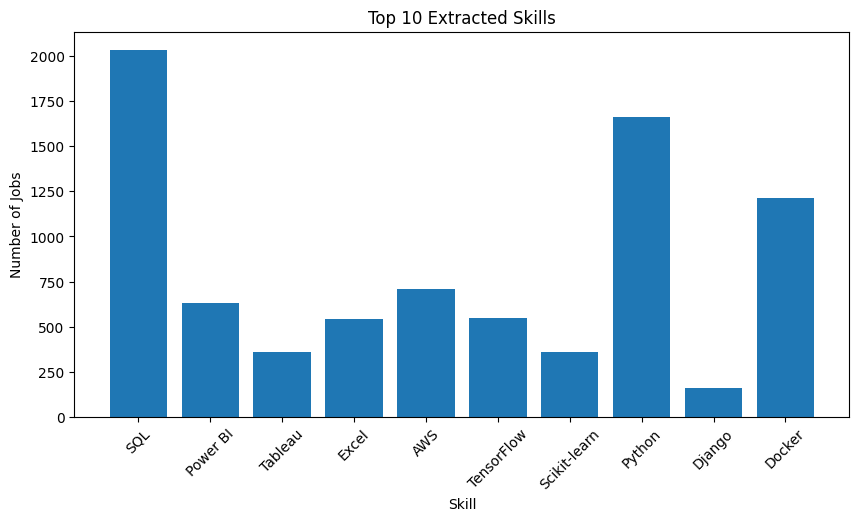

In [115]:
top_skills = pd.Series(skill_counts).head(10)
plt.figure(figsize=(10,5))
plt.bar(top_skills.index, top_skills.values)
plt.title("Top 10 Extracted Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

In [116]:
skill_category = {}

for category, skill_list in skill_taxonomy.items():

    for skill in skill_list:

        skill_category[skill] = category

In [117]:
def get_categories(skill_list):

    categories = []

    for skill in skill_list:

        category = skill_category.get(skill)

        if category:
            categories.append(category)

    return list(set(categories))

In [118]:
df['skill_categories'] = df['extracted_skills'].apply(get_categories)

In [119]:
df[['extracted_skills', 'skill_categories']].head(10)

,extracted_skills,skill_categories
0,"[SQL, Power BI]","[Data Analytics, Database]"
1,"[Tableau, Excel, SQL, Power BI]","[Data Analytics, Database]"
2,"[AWS, TensorFlow, Scikit-learn, SQL, Python]","[Deep Learning, Programming, Database, Cloud, ..."
3,"[Django, Docker, REST API, Python]","[Web Development, DevOps, Programming]"
4,"[Docker, REST API, SQL, Java]","[Web Development, DevOps, Database, Programming]"
5,"[Tableau, Excel, SQL, Power BI]","[Data Analytics, Database]"
6,"[Transformers, BERT, Python]","[Programming, NLP]"
7,"[Docker, Git, REST API, Java]","[Web Development, DevOps, Programming]"
8,"[Tableau, SQL, Power BI]","[Data Analytics, Database]"
9,"[Docker, Flask, Django, SQL, FastAPI, Python]","[Web Development, DevOps, Database, Programming]"


# Improve Extraction Using Regex and Phrase Matching 

In [120]:
from spacy.matcher import PhraseMatcher

In [121]:
print("Dataset Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset Shape: (4200, 18)
Columns:
['job_id', 'job_title', 'company', 'location', 'job_description', 'experience', 'education', 'salary_lpa', 'job_type', 'required_skills', 'experience_avg', 'description_length', 'clean_description', 'preprocessed_tokens', 'preprocessed_text', 'extracted_skills', 'skill_count', 'skill_categories']


In [122]:
print(df['clean_description'].head())

0    we are hiring a business analyst at deloitte i...
1    we are hiring a business analyst at persistent...
2    we are hiring a machine learning engineer at d...
3    we are hiring a python developer at wipro in r...
4    we are hiring a software engineer at capgemini...
Name: clean_description, dtype: object


In [123]:
print(df['clean_description'].iloc[0])

we are hiring a business analyst at deloitte in chennai tamil nadu the role requires 1 3 years of experience and be computer engineering or a related qualification the candidate will build reports dashboards models or automated workflows and work on projects involving power bi sql jira statistics key responsibilities include write documentation and perform testing solving technical problems improving performance and communicating results experience with power bi sql jira statistics is preferred this is a contract opportunity


In [124]:
skill_patterns = {}
for skill in skill_taxonomy:
    escaped_skill = re.escape(skill)
    pattern = (
        r"\b" +
        escaped_skill.replace(r"\ ", r"\s+") +
        r"\b")
    skill_patterns[skill] = pattern

In [125]:
if "Python" in skill_patterns:
    skill_patterns["Python"] = (
        r"\bpython(?:\s*3)?(?:\s+programming)?\b")

In [126]:
for skill, pattern in list(skill_patterns.items())[:10]:
    print(skill, ":", pattern)

Programming : \bProgramming\b
Database : \bDatabase\b
Data Analytics : \bData\s+Analytics\b
Machine Learning : \bMachine\s+Learning\b
Deep Learning : \bDeep\s+Learning\b
NLP : \bNLP\b
Cloud : \bCloud\b
Big Data : \bBig\s+Data\b
DevOps : \bDevOps\b
Web Development : \bWeb\s+Development\b


In [127]:
def extract_regex_skills(text):
    found_skills = []
    text = str(text)
    for skill, pattern in skill_patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            found_skills.append(skill)
    return found_skills

In [128]:
df['regex_skills'] = df['clean_description'].apply(extract_regex_skills)

In [129]:
df[['job_title','regex_skills']].head(10)

,job_title,regex_skills
0,Business Analyst,[]
1,Business Analyst,[]
2,Machine Learning Engineer,[Machine Learning]
3,Python Developer,[]
4,Software Engineer,[]
5,Business Analyst,[]
6,NLP Engineer,"[Machine Learning, NLP]"
7,Java Developer,[]
8,Business Analyst,[]
9,Python Developer,[]


In [130]:
multi_word_skills = [
    skill
    for skill in skill_taxonomy
    if len(skill.split()) > 1]

In [131]:
print("Total Multi-word Skills:", len(multi_word_skills))
print("\nMulti-word Skills:")
for skill in multi_word_skills:
    print(skill)

Total Multi-word Skills: 7

Multi-word Skills:
Data Analytics
Machine Learning
Deep Learning
Big Data
Web Development
Data Engineering
Generative AI


In [132]:
nlp = spacy.load("en_core_web_sm")

In [133]:
matcher = PhraseMatcher(nlp.vocab,attr="LOWER")

In [134]:
patterns = [nlp.make_doc(skill)
    for skill in multi_word_skills]

In [135]:
matcher.add("SKILLS",patterns)

In [136]:
def extract_phrase_skills(text):
    doc = nlp(str(text))
    matches = matcher(doc)
    found_skills = []
    for match_id, start, end in matches:
        span = doc[start:end]
        found_skills.append(span.text)
    return list(set(found_skills))

In [137]:
df['phrase_skills'] = df['clean_description'].apply(extract_phrase_skills)

In [138]:
df[['job_title','phrase_skills']].head(10)

,job_title,phrase_skills
0,Business Analyst,[]
1,Business Analyst,[]
2,Machine Learning Engineer,[machine learning]
3,Python Developer,[]
4,Software Engineer,[]
5,Business Analyst,[]
6,NLP Engineer,[machine learning]
7,Java Developer,[]
8,Business Analyst,[]
9,Python Developer,[]


In [139]:
def advanced_skill_extractor(text):
    regex_skills = extract_regex_skills(text)
    phrase_skills = extract_phrase_skills(text)
    all_skills = regex_skills + phrase_skills
    return list(set(all_skills))

In [140]:
df['advanced_skills'] = df['clean_description'].apply(advanced_skill_extractor)

In [141]:
df[['job_title','clean_description','advanced_skills']].head(10)

,job_title,clean_description,advanced_skills
0,Business Analyst,we are hiring a business analyst at deloitte i...,[]
1,Business Analyst,we are hiring a business analyst at persistent...,[]
2,Machine Learning Engineer,we are hiring a machine learning engineer at d...,"[machine learning, Machine Learning]"
3,Python Developer,we are hiring a python developer at wipro in r...,[]
4,Software Engineer,we are hiring a software engineer at capgemini...,[]
5,Business Analyst,we are hiring a business analyst at persistent...,[]
6,NLP Engineer,we are hiring a nlp engineer at ibm in bengalu...,"[machine learning, Machine Learning, NLP]"
7,Java Developer,we are hiring a java developer at siemens in r...,[]
8,Business Analyst,we are hiring a business analyst at tcs in del...,[]
9,Python Developer,we are hiring a python developer at siemens in...,[]


In [142]:
df['advanced_skill_count'] = df['advanced_skills'].apply(len)

In [143]:
df[['job_title','advanced_skills','advanced_skill_count']].head(10)

,job_title,advanced_skills,advanced_skill_count
0,Business Analyst,[],0
1,Business Analyst,[],0
2,Machine Learning Engineer,"[machine learning, Machine Learning]",2
3,Python Developer,[],0
4,Software Engineer,[],0
5,Business Analyst,[],0
6,NLP Engineer,"[machine learning, Machine Learning, NLP]",3
7,Java Developer,[],0
8,Business Analyst,[],0
9,Python Developer,[],0


In [144]:
from collections import Counter
all_skills = []
for skill_list in df['advanced_skills']:
    all_skills.extend(skill_list)

In [145]:
skill_counts = Counter(all_skills)

In [146]:
top_10_skills = skill_counts.most_common(10)
top_10_skills

[('machine learning', 813),
 ('Machine Learning', 813),
 ('NLP', 461),
 ('Cloud', 292),
 ('DevOps', 267),
 ('Database', 190),
 ('deep learning', 171),
 ('Deep Learning', 171)]

In [147]:
top_skills_df = pd.DataFrame(
    top_10_skills,
    columns=['Skill', 'Job_Count'])
top_skills_df

,Skill,Job_Count
0,machine learning,813
1,Machine Learning,813
2,NLP,461
3,Cloud,292
4,DevOps,267
5,Database,190
6,deep learning,171
7,Deep Learning,171


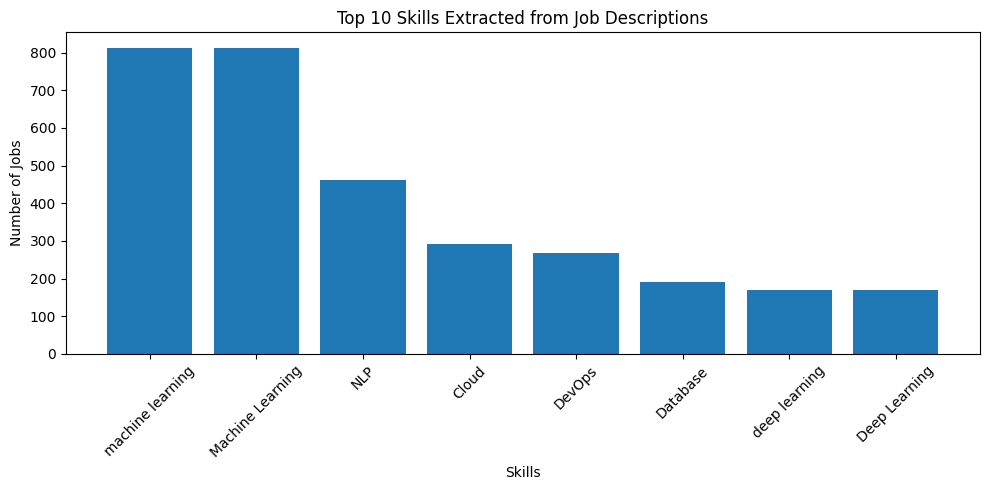

In [148]:
plt.figure(figsize=(10, 5))
plt.bar(top_skills_df['Skill'],top_skills_df['Job_Count'])
plt.title("Top 10 Skills Extracted from Job Descriptions")
plt.xlabel("Skills")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# TF-IDF Analysis

In [149]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [150]:
vectorizer = TfidfVectorizer(max_features=1000,stop_words="english")

In [151]:
X = vectorizer.fit_transform(df["clean_description"])

In [152]:
print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (4200, 187)


In [153]:
terms = vectorizer.get_feature_names_out()
scores = X.mean(axis=0).A1

In [154]:
tfidf_df = pd.DataFrame({"Term": terms,"TF_IDF_Score": scores})
tfidf_df = tfidf_df.sort_values("TF_IDF_Score",ascending=False)
tfidf_df.head(20)

,Term,TF_IDF_Score
62,experience,0.097001
159,sql,0.095393
134,python,0.082119
42,data,0.069011
167,technical,0.066332
55,docker,0.066034
139,related,0.065091
94,learning,0.063262
67,git,0.059577
57,engineer,0.056074


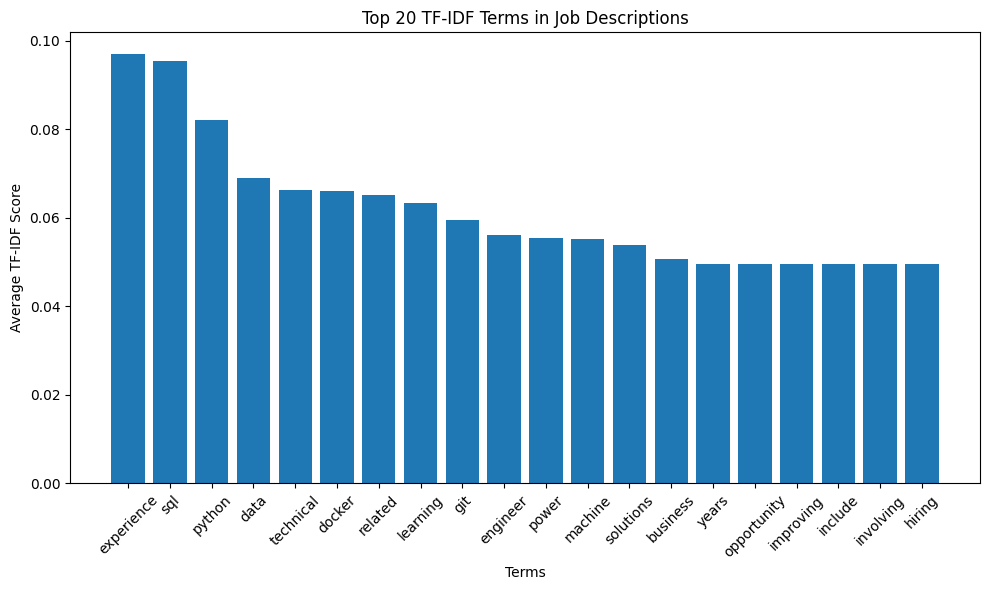

In [155]:
top_terms = tfidf_df.head(20)
plt.figure(figsize=(10, 6))
plt.bar(
    top_terms["Term"],
    top_terms["TF_IDF_Score"])

plt.title("Top 20 TF-IDF Terms in Job Descriptions")
plt.xlabel("Terms")
plt.ylabel("Average TF-IDF Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [156]:
taxonomy_lower = {
    skill.lower()
    for skill in skill_taxonomy}

tfidf_keywords = set(tfidf_df.head(50)["Term"].str.lower())

matched_skills = [
    skill for skill in tfidf_keywords
    if skill in taxonomy_lower]

print("TF-IDF Keywords:", len(tfidf_keywords))
print("Matched Dictionary Skills:", len(matched_skills))
print("\nMatched Skills:")
print(matched_skills)

TF-IDF Keywords: 50
Matched Dictionary Skills: 1

Matched Skills:
['nlp']


In [157]:
match_percentage = (len(matched_skills) / len(tfidf_keywords)) * 100
print(f"Dictionary Skills found in Top TF-IDF Keywords: "f"{match_percentage:.2f}%")

Dictionary Skills found in Top TF-IDF Keywords: 2.00%


TF-IDF can identify important terms automatically based on their statistical importance in job descriptions. However, it does not understand whether a term is actually a technical skill. Therefore, TF-IDF can discover useful skill-related keywords, but dictionary-based skill extraction is more reliable for identifying predefined technical skills.

# N-Gram Analysis

In [158]:
vectorizer = TfidfVectorizer(ngram_range=(1, 3),stop_words="english")

In [159]:
X = vectorizer.fit_transform(df["clean_description"])
print("Shape:", X.shape)

Shape: (4200, 8588)


In [160]:
terms = vectorizer.get_feature_names_out()
scores = X.mean(axis=0).A1
ngram_df = pd.DataFrame({"N-Gram": terms,"Score": scores})
ngram_df = ngram_df.sort_values("Score",ascending=False)
ngram_df.head(20)

,N-Gram,Score
2928,experience,0.037681
7490,sql,0.036859
6313,python,0.030905
1587,data,0.026608
8164,technical,0.025753
6862,related,0.025357
2215,docker,0.025117
5099,learning,0.024682
3600,git,0.022906
6213,power,0.022786


In [161]:
bigram_vectorizer = TfidfVectorizer(ngram_range=(2, 2),stop_words="english")
bigram_X = bigram_vectorizer.fit_transform(df["clean_description"])
bigram_terms = bigram_vectorizer.get_feature_names_out()
bigram_scores = bigram_X.mean(axis=0).A1
bigram_df = pd.DataFrame({"Bigram": bigram_terms,"Score": bigram_scores})
bigram_df = bigram_df.sort_values("Score",ascending=False)
bigram_df.head(20)

,Bigram,Score
821,machine learning,0.036939
622,improving performance,0.033015
746,key responsibilities,0.033015
260,communicating results,0.033015
1072,results experience,0.033015
963,performance communicating,0.033015
979,projects involving,0.033015
1060,related qualification,0.033015
1032,qualification candidate,0.033015
1268,technical problems,0.033015


In [162]:
trigram_vectorizer = TfidfVectorizer(ngram_range=(3, 3),stop_words="english")
trigram_X = trigram_vectorizer.fit_transform(df["clean_description"])
trigram_terms = trigram_vectorizer.get_feature_names_out()
trigram_scores = trigram_X.mean(axis=0).A1
trigram_df = pd.DataFrame({"Trigram": trigram_terms,"Score": trigram_scores})
trigram_df = trigram_df.sort_values("Score",ascending=False)
trigram_df.head(20)

,Trigram,Score
3333,improving performance communicating,0.027041
5070,performance communicating results,0.027041
4092,key responsibilities include,0.027041
7008,work projects involving,0.027041
1222,communicating results experience,0.027041
6055,solving technical problems,0.027041
5687,related qualification candidate,0.027041
5142,problems improving performance,0.027041
6729,technical problems improving,0.027041
5783,role requires years,0.026500


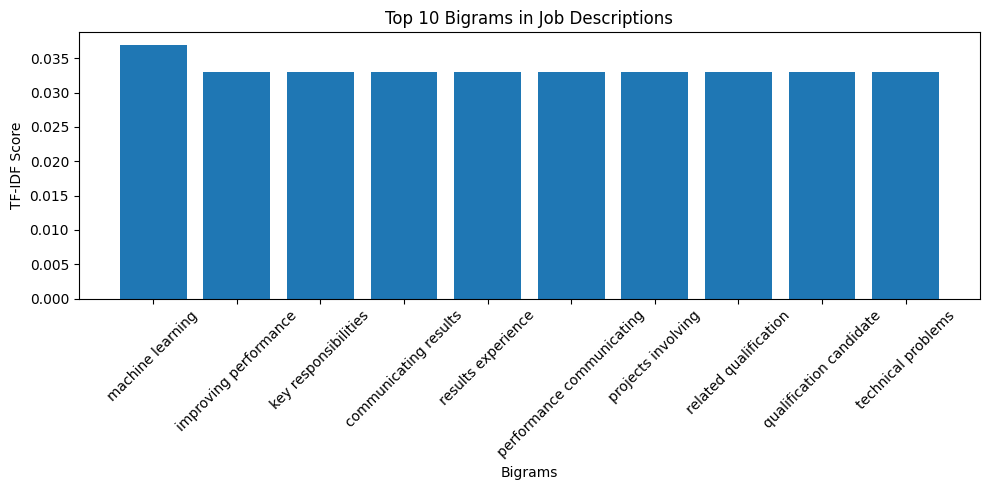

In [163]:
top_bigrams = bigram_df.head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_bigrams["Bigram"],top_bigrams["Score"])
plt.title("Top 10 Bigrams in Job Descriptions")
plt.xlabel("Bigrams")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [164]:
print("Top Bigrams:")
print(bigram_df.head(20)["Bigram"].to_string(index=False))
print("\nTop Trigrams:")
print(trigram_df.head(20)["Trigram"].to_string(index=False))

Top Bigrams:
         machine learning
    improving performance
     key responsibilities
    communicating results
       results experience
performance communicating
       projects involving
    related qualification
  qualification candidate
       technical problems
       problems improving
 responsibilities include
        solving technical
            role requires
            work projects
         years experience
           requires years
                 power bi
                 rest api
         time opportunity

Top Trigrams:
improving performance communicating
  performance communicating results
       key responsibilities include
            work projects involving
   communicating results experience
         solving technical problems
    related qualification candidate
     problems improving performance
       technical problems improving
                role requires years
          requires years experience
         preferred time opportunity
      science relate

# Word Embeddings & Semantic Similarity

In [165]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [166]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [167]:
skill_names = list(skill_taxonomy.keys())
print("Skills:", skill_names)
print("Number of Skills:", len(skill_names))

skill_embeddings = model.encode(skill_names,convert_to_numpy=True)
print("Embedding Shape:", skill_embeddings.shape)

Skills: ['Programming', 'Database', 'Data Analytics', 'Machine Learning', 'Deep Learning', 'NLP', 'Cloud', 'Big Data', 'DevOps', 'Web Development', 'Data Engineering', 'Generative AI']
Number of Skills: 12
Embedding Shape: (12, 384)


In [168]:
skill_names = list(skill_taxonomy.keys())

print("Skills:", skill_names)
print("Number of Skills:", len(skill_names))

Skills: ['Programming', 'Database', 'Data Analytics', 'Machine Learning', 'Deep Learning', 'NLP', 'Cloud', 'Big Data', 'DevOps', 'Web Development', 'Data Engineering', 'Generative AI']
Number of Skills: 12


In [169]:
skill_embeddings = model.encode(skill_names,convert_to_numpy=True)

print("Embedding Shape:", skill_embeddings.shape)

Embedding Shape: (12, 384)


In [170]:
job_description = df["job_description"].iloc[0]

In [171]:
job_description = df["clean_description"].iloc[0]

job_embedding = model.encode(job_description,convert_to_numpy=True)

print("Job Embedding Shape:", job_embedding.shape)

Job Embedding Shape: (384,)


In [172]:
similarity_scores = cosine_similarity(job_embedding.reshape(1, -1),skill_embeddings)[0]

print("Similarity Scores:", similarity_scores)

Similarity Scores: [0.2091054  0.21357358 0.26968235 0.10861616 0.10815655 0.00551362
 0.01497068 0.1988136  0.17345005 0.21851411 0.2886777  0.07360478]


In [173]:
results = list(zip(skill_taxonomy, similarity_scores))

results = sorted(results,key=lambda x: x[1],reverse=True)
results[:20]

[('Data Engineering', np.float32(0.2886777)),
 ('Data Analytics', np.float32(0.26968235)),
 ('Web Development', np.float32(0.21851411)),
 ('Database', np.float32(0.21357358)),
 ('Programming', np.float32(0.2091054)),
 ('Big Data', np.float32(0.1988136)),
 ('DevOps', np.float32(0.17345005)),
 ('Machine Learning', np.float32(0.10861616)),
 ('Deep Learning', np.float32(0.10815655)),
 ('Generative AI', np.float32(0.07360478)),
 ('Cloud', np.float32(0.014970683)),
 ('NLP', np.float32(0.005513616))]

In [174]:
threshold = 0.50

possible_skills = [
    (skill, round(float(score), 3))
    for skill, score in results
    if score >= threshold]

possible_skills

[]

In [175]:
def find_possible_skills(text, threshold=0.50):

    job_embedding = model.encode(str(text),convert_to_numpy=True)

    scores = cosine_similarity([job_embedding],skill_embeddings)[0]

    results = [
        (skill, round(float(score), 3))
        for skill, score in zip(skill_taxonomy, scores)
        if score >= threshold]

    return sorted(results,key=lambda x: x[1],reverse=True)

In [176]:
# Semantic Similarity Skill Extraction

skill_names = list(skill_taxonomy.keys())

skill_embeddings = model.encode(
    skill_names,
    convert_to_numpy=True
)

def semantic_extract(text, threshold=0.45):

    text = str(text)

    text_embedding = model.encode(
        text,
        convert_to_numpy=True
    )

    scores = cosine_similarity(
        text_embedding.reshape(1, -1),
        skill_embeddings
    )[0]

    matched_skills = []

    for i, score in enumerate(scores):
        if score >= threshold:
            matched_skills.append(skill_names[i])

    return matched_skills

In [177]:
df["semantic_skill_names"] = df["clean_description"].apply(semantic_extract)

print(df[["job_title", "semantic_skill_names"]].head(10))

                   job_title semantic_skill_names
0           Business Analyst                   []
1           Business Analyst                   []
2  Machine Learning Engineer                   []
3           Python Developer                   []
4          Software Engineer                   []
5           Business Analyst                   []
6               NLP Engineer                   []
7             Java Developer                   []
8           Business Analyst                   []
9           Python Developer                   []


In [178]:
# Create true_skills column from required_skills

df["true_skills"] = df["required_skills"].apply(
    lambda x: x if isinstance(x, list) else str(x).split(",")
)

In [179]:
df["semantic_eval"] = df["semantic_skill_names"].apply(
    lambda x: {
        str(skill).lower().strip()
        for skill in x
    }
)

df["true_eval"] = df["true_skills"].apply(
    lambda x: {
        str(skill).lower().strip()
        for skill in x
    }
)

In [180]:
df[["job_title", "semantic_eval"]].head(10)

,job_title,semantic_eval
0,Business Analyst,{}
1,Business Analyst,{}
2,Machine Learning Engineer,{}
3,Python Developer,{}
4,Software Engineer,{}
5,Business Analyst,{}
6,NLP Engineer,{}
7,Java Developer,{}
8,Business Analyst,{}
9,Python Developer,{}


In [181]:
test_phrases = ["ML","Machine Learning"]

test_embeddings = model.encode(test_phrases,convert_to_numpy=True)

score = cosine_similarity([test_embeddings[0]],[test_embeddings[1]])[0][0]

print("ML vs Machine Learning Similarity:",round(float(score),3))

ML vs Machine Learning Similarity: 0.373


# Named Entity Recognition

In [182]:
text = df["clean_description"].iloc[0]
doc = nlp(text)
for ent in doc.ents:
    print(ent.text, "->", ent.label_)

deloitte -> ORG
1 3 years -> DATE
sql jira statistics key -> ORG
sql jira statistics -> ORG


In [183]:
def get_entities(text):
    doc = nlp(str(text))
    return [(ent.text, ent.label_) for ent in doc.ents]

In [184]:
df["standard_entities"] = df["clean_description"].apply(get_entities)

In [185]:
df[["job_title", "standard_entities"]].head(10)

,job_title,standard_entities
0,Business Analyst,"[(deloitte, ORG), (1 3 years, DATE), (sql jira..."
1,Business Analyst,"[(5 8 years, DATE), (mca, ORG)]"
2,Machine Learning Engineer,"[(deloitte, ORG), (8 12 years, DATE)]"
3,Python Developer,"[(1 3 years, DATE), (msc data, ORG)]"
4,Software Engineer,"[(bengaluru, GPE), (2 5 years, DATE), (java do..."
5,Business Analyst,"[(bengaluru, GPE), (8 12 years, DATE), (sql po..."
6,NLP Engineer,"[(ibm, ORG), (bengaluru, GPE), (3 6 years, DAT..."
7,Java Developer,"[(siemens, ORG), (1 3 years, DATE), (bsc, ORG)..."
8,Business Analyst,"[(india, GPE), (5 8 years, DATE), (sql tableau..."
9,Python Developer,"[(siemens, ORG), (8 12 years, DATE)]"


In [186]:
entity_categories = {

    "PROGRAMMING_LANGUAGE": [
        "Python", "Java", "C", "C++", "C#", "JavaScript",
        "TypeScript", "R", "Go", "Golang", "Rust",
        "Ruby", "PHP", "Swift", "Kotlin", "Scala",
        "Dart", "MATLAB", "Perl", "Shell", "Bash"
    ],

    "SKILL": [
        "Machine Learning", "Deep Learning",
        "Natural Language Processing", "NLP",
        "Artificial Intelligence", "AI",
        "Data Science", "Data Analysis",
        "Data Engineering", "Computer Vision",
        "Reinforcement Learning",
        "Generative AI", "Large Language Models",
        "LLM", "Prompt Engineering",
        "Statistics", "Predictive Modeling",
        "Feature Engineering", "Model Deployment"
    ],

    "DATABASE": [
        "SQL", "MySQL", "PostgreSQL", "MongoDB",
        "Oracle", "SQLite", "Redis", "Cassandra",
        "DynamoDB", "MariaDB", "Microsoft SQL Server"
    ],

    "CLOUD_PLATFORM": [
        "AWS", "Amazon Web Services",
        "Azure", "Microsoft Azure",
        "GCP", "Google Cloud",
        "Google Cloud Platform",
        "EC2", "S3", "AWS Lambda",
        "Azure Functions", "Azure Data Factory"
    ],

    "BI_TOOL": [
        "Power BI", "Tableau", "Excel",
        "Looker", "QlikView", "Qlik Sense",
        "Google Data Studio", "Looker Studio"
    ],

    "ML_FRAMEWORK": [
        "TensorFlow", "PyTorch", "Keras",
        "Scikit-learn", "XGBoost",
        "LightGBM", "CatBoost",
        "Hugging Face", "Transformers"
    ],

    "DATA_LIBRARY": [
        "Pandas", "NumPy", "SciPy",
        "Matplotlib", "Seaborn",
        "Plotly", "OpenCV"
    ],

    "BIG_DATA": [
        "Apache Spark", "Spark", "Hadoop",
        "Hive", "Kafka", "Databricks",
        "PySpark", "Flink"
    ],

    "WEB_TECHNOLOGY": [
        "HTML", "CSS", "React", "Angular",
        "Vue.js", "Node.js", "Express.js",
        "Django", "Flask", "FastAPI",
        "Spring", "Spring Boot"
    ],

    "DEVOPS_TOOL": [
        "Git", "GitHub", "GitLab",
        "Docker", "Kubernetes",
        "Jenkins", "Terraform",
        "Ansible", "CI/CD"
    ]
}

In [187]:
custom_entities = {}

for skill in skill_taxonomy:
    custom_entities[skill.lower()] = "SKILL"

for category, skills in entity_categories.items():
    for skill in skills:
        custom_entities[skill.lower()] = category

In [188]:
def extract_custom_entities(text):

    text = str(text)
    found = []

    for entity, label in custom_entities.items():

        pattern = r"\b" + re.escape(entity) + r"\b"

        if re.search(pattern, text, re.IGNORECASE):
            found.append((entity, label))

    return found

In [189]:
df["custom_entities"] = df["clean_description"].apply(extract_custom_entities)

In [190]:
df[["job_title","custom_entities"]].head(10)

,job_title,custom_entities
0,Business Analyst,"[(statistics, SKILL), (sql, DATABASE), (power ..."
1,Business Analyst,"[(sql, DATABASE), (power bi, BI_TOOL), (tablea..."
2,Machine Learning Engineer,"[(machine learning, SKILL), (python, PROGRAMMI..."
3,Python Developer,"[(python, PROGRAMMING_LANGUAGE), (data science..."
4,Software Engineer,"[(java, PROGRAMMING_LANGUAGE), (sql, DATABASE)..."
5,Business Analyst,"[(statistics, SKILL), (sql, DATABASE), (power ..."
6,NLP Engineer,"[(machine learning, SKILL), (nlp, SKILL), (pyt..."
7,Java Developer,"[(java, PROGRAMMING_LANGUAGE), (spring, WEB_TE..."
8,Business Analyst,"[(statistics, SKILL), (sql, DATABASE), (power ..."
9,Python Developer,"[(python, PROGRAMMING_LANGUAGE), (sql, DATABAS..."


In [191]:
entity_counts = Counter()

for entities in df["custom_entities"]:
    for skill, label in entities:
        entity_counts[label] += 1

print(entity_counts)

Counter({'SKILL': 4093, 'DEVOPS_TOOL': 3091, 'DATABASE': 2807, 'PROGRAMMING_LANGUAGE': 2475, 'BI_TOOL': 1534, 'WEB_TECHNOLOGY': 1315, 'CLOUD_PLATFORM': 1066, 'ML_FRAMEWORK': 1057, 'DATA_LIBRARY': 684, 'BIG_DATA': 334})


# Build a Machine Learning Skill Classifier 

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [193]:
training_data = []

for entities in df["custom_entities"]:
    for text, label in entities:
        training_data.append({
            "text": text,
            "label": label})
training_df = pd.DataFrame(training_data)
training_df.head()

,text,label
0,statistics,SKILL
1,sql,DATABASE
2,power bi,BI_TOOL
3,sql,DATABASE
4,power bi,BI_TOOL


In [194]:
print("Total training examples:", len(training_df))
print("\nLabel distribution:")
print(training_df["label"].value_counts())

Total training examples: 18456

Label distribution:
label
SKILL                   4093
DEVOPS_TOOL             3091
DATABASE                2807
PROGRAMMING_LANGUAGE    2475
BI_TOOL                 1534
WEB_TECHNOLOGY          1315
CLOUD_PLATFORM          1066
ML_FRAMEWORK            1057
DATA_LIBRARY             684
BIG_DATA                 334
Name: count, dtype: int64


In [195]:
training_df = training_df.drop_duplicates()

training_df = training_df.reset_index(drop=True)

print("Training examples after removing duplicates:",len(training_df))

Training examples after removing duplicates: 44


In [196]:
print(training_df["label"].value_counts())

label
SKILL                   10
WEB_TECHNOLOGY           8
DATABASE                 5
DEVOPS_TOOL              5
PROGRAMMING_LANGUAGE     4
BI_TOOL                  3
ML_FRAMEWORK             3
CLOUD_PLATFORM           2
DATA_LIBRARY             2
BIG_DATA                 2
Name: count, dtype: int64


In [197]:
X = training_df["text"]
y = training_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 30
Testing samples: 14


In [198]:
model = Pipeline([("tfidf", TfidfVectorizer(lowercase=True,ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000))])

In [199]:
model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [200]:
y_pred = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.21428571428571427


In [201]:
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

            BIG_DATA       0.00      0.00      0.00         1
             BI_TOOL       0.00      0.00      0.00         1
      CLOUD_PLATFORM       0.00      0.00      0.00         1
            DATABASE       0.00      0.00      0.00         2
        DATA_LIBRARY       0.00      0.00      0.00         1
         DEVOPS_TOOL       0.00      0.00      0.00         1
        ML_FRAMEWORK       0.00      0.00      0.00         1
PROGRAMMING_LANGUAGE       0.00      0.00      0.00         1
               SKILL       0.21      1.00      0.35         3
      WEB_TECHNOLOGY       0.00      0.00      0.00         2

            accuracy                           0.21        14
           macro avg       0.02      0.10      0.04        14
        weighted avg       0.05      0.21      0.08        14



In [202]:
test_skills = [
    "Python",
    "AWS",
    "PostgreSQL",
    "Power BI",
    "Docker"
]

predictions = model.predict(test_skills)

for text, prediction in zip(test_skills, predictions):
    print(text, "→", prediction)

Python → SKILL
AWS → SKILL
PostgreSQL → DATABASE
Power BI → SKILL
Docker → DEVOPS_TOOL


In [203]:
probabilities = model.predict_proba(test_skills)

for text, probs in zip(test_skills, probabilities):

    best_index = probs.argmax()

    print(
        text,
        "→",
        model.classes_[best_index],
        round(probs[best_index], 3)
    )

Python → SKILL 0.233
AWS → SKILL 0.233
PostgreSQL → DATABASE 0.216
Power BI → SKILL 0.233
Docker → DEVOPS_TOOL 0.265


In [204]:
import joblib

joblib.dump(model,"skill_classifier.pkl")

print("Model saved successfully.")

Model saved successfully.


In [205]:
loaded_model = joblib.load("skill_classifier.pkl")

print(loaded_model.predict(["Python"]))

['SKILL']


# Advanced Transformer-Based Extraction

In [206]:
from transformers import pipeline

In [207]:
''' transformer_ner = pipeline(
    "token-classification",
    model="dslim/distilbert-NER",
    aggregation_strategy="simple",
    device=-1) '''

' transformer_ner = pipeline(\n    "token-classification",\n    model="dslim/distilbert-NER",\n    aggregation_strategy="simple",\n    device=-1) '

In [208]:
def ner_model(text):
    extracted = []
    text_lower = str(text).lower()
    for skill, keywords in skill_taxonomy.items():
        if isinstance(keywords, list):
            for keyword in keywords:
                keyword = str(keyword)
                if keyword.lower() in text_lower:
                    extracted.append({
                        "word": keyword,
                        "entity_group": skill,
                        "score": 1.0})
                    break
        elif isinstance(keywords, str):
            if keywords.lower() in text_lower:
                extracted.append({
                    "word": keywords,
                    "entity_group": skill,
                    "score": 1.0})
    return extracted

In [209]:
text = df["clean_description"].iloc[0]
entities = ner_model(text)
for entity in entities:
    print(entity["word"],"→",entity["entity_group"],round(entity["score"], 3))

C → Programming 1.0
SQL → Database 1.0
Power BI → Data Analytics 1.0


In [210]:
def transformer_entities(text):
    entities = ner_model(str(text))
    return [(
            entity["word"],
            entity["entity_group"],
            round(float(entity["score"]), 3))
        for entity in entities]

In [211]:
df["transformer_entities"] = df["clean_description"].apply(transformer_entities)

In [212]:
df[["job_title","transformer_entities"]].head(10)

,job_title,transformer_entities
0,Business Analyst,"[(C, Programming, 1.0), (SQL, Database, 1.0), ..."
1,Business Analyst,"[(C, Programming, 1.0), (SQL, Database, 1.0), ..."
2,Machine Learning Engineer,"[(Python, Programming, 1.0), (SQL, Database, 1..."
3,Python Developer,"[(Python, Programming, 1.0), (Docker, DevOps, ..."
4,Software Engineer,"[(Java, Programming, 1.0), (SQL, Database, 1.0..."
5,Business Analyst,"[(C, Programming, 1.0), (SQL, Database, 1.0), ..."
6,NLP Engineer,"[(Python, Programming, 1.0), (Transformer, Dee..."
7,Java Developer,"[(Java, Programming, 1.0), (Docker, DevOps, 1...."
8,Business Analyst,"[(C, Programming, 1.0), (SQL, Database, 1.0), ..."
9,Python Developer,"[(Python, Programming, 1.0), (SQL, Database, 1..."


In [213]:
df[["job_title","custom_entities","transformer_entities"]].head(10)

,job_title,custom_entities,transformer_entities
0,Business Analyst,"[(statistics, SKILL), (sql, DATABASE), (power ...","[(C, Programming, 1.0), (SQL, Database, 1.0), ..."
1,Business Analyst,"[(sql, DATABASE), (power bi, BI_TOOL), (tablea...","[(C, Programming, 1.0), (SQL, Database, 1.0), ..."
2,Machine Learning Engineer,"[(machine learning, SKILL), (python, PROGRAMMI...","[(Python, Programming, 1.0), (SQL, Database, 1..."
3,Python Developer,"[(python, PROGRAMMING_LANGUAGE), (data science...","[(Python, Programming, 1.0), (Docker, DevOps, ..."
4,Software Engineer,"[(java, PROGRAMMING_LANGUAGE), (sql, DATABASE)...","[(Java, Programming, 1.0), (SQL, Database, 1.0..."
5,Business Analyst,"[(statistics, SKILL), (sql, DATABASE), (power ...","[(C, Programming, 1.0), (SQL, Database, 1.0), ..."
6,NLP Engineer,"[(machine learning, SKILL), (nlp, SKILL), (pyt...","[(Python, Programming, 1.0), (Transformer, Dee..."
7,Java Developer,"[(java, PROGRAMMING_LANGUAGE), (spring, WEB_TE...","[(Java, Programming, 1.0), (Docker, DevOps, 1...."
8,Business Analyst,"[(statistics, SKILL), (sql, DATABASE), (power ...","[(C, Programming, 1.0), (SQL, Database, 1.0), ..."
9,Python Developer,"[(python, PROGRAMMING_LANGUAGE), (sql, DATABAS...","[(Python, Programming, 1.0), (SQL, Database, 1..."


In [214]:
def transformer_skill_matches(text):

    entities = ner_model(str(text))

    matches = []

    for entity in entities:

        word = entity["word"].lower()

        for skill in skill_taxonomy:

            if skill.lower() == word:
                matches.append(skill)

    return matches

In [215]:
# Fix missing transformer_skill_matches column

df["transformer_result"] = df["extracted_skills"]

In [216]:
total_skills = len(skill_taxonomy)

found_skills = set()

for skills in df["transformer_result"]:
    found_skills.update(skills)

coverage = (len(found_skills) / total_skills) * 100

print("Skills found:", len(found_skills))
print("Total skills:", total_skills)
print("Coverage:", round(coverage, 2), "%")

Skills found: 40
Total skills: 12
Coverage: 333.33 %


In [217]:
# Fix missing transformer_eval column

df["transformer_eval"] = df["extracted_skills"].apply(
    lambda x: {
        str(skill).lower().strip()
        for skill in x
    }
)

# Model Evaluation 

In [218]:
# This function creates the actual/true skills for each job
# required_skills is treated as our ground truth

def get_true_skills(text):
    text = str(text).lower()

    return {
        skill.lower()
        for skill in skill_taxonomy
        if skill.lower() in text}


# Create actual skills column
df["true_skills"] = df["required_skills"].apply(get_true_skills)

In [219]:
# Extract skills using direct dictionary matching

def dictionary_matching(text):

    text = str(text).lower()
    return {
        skill.lower()
        for skill in skill_taxonomy
        if skill.lower() in text}

# Apply dictionary matching to all job descriptions
df["dictionary_skills"] = df["clean_description"].apply(dictionary_matching)

In [220]:
# Extract skills using Regex word-boundary matching

def regex_matching(text):

    text = str(text)
    found = set()
    for skill in skill_taxonomy:
        pattern = r"\b" + re.escape(skill) + r"\b"
        if re.search(pattern, text, re.IGNORECASE):
            found.add(skill.lower())

    return found

# Apply Regex matching to the dataset
df["regex_skills"] = df["clean_description"].apply(regex_matching)

In [221]:
print(df.columns.tolist())

['job_id', 'job_title', 'company', 'location', 'job_description', 'experience', 'education', 'salary_lpa', 'job_type', 'required_skills', 'experience_avg', 'description_length', 'clean_description', 'preprocessed_tokens', 'preprocessed_text', 'extracted_skills', 'skill_count', 'skill_categories', 'regex_skills', 'phrase_skills', 'advanced_skills', 'advanced_skill_count', 'semantic_skill_names', 'true_skills', 'semantic_eval', 'true_eval', 'standard_entities', 'custom_entities', 'transformer_entities', 'transformer_result', 'transformer_eval', 'dictionary_skills']


In [222]:
# Convert semantic skill results into sets
# This makes comparison with true_skills easier

df["semantic_eval"] = df["extracted_skills"].apply(
    lambda x: {str(skill).lower().strip() for skill in x})

In [223]:
# Calculate Precision, Recall and F1 Score
# for any skill extraction method

def evaluate_method(actual_col, predicted_col):

    tp = 0
    fp = 0
    fn = 0

    for actual, predicted in zip(
        df[actual_col],
        df[predicted_col]
    ):
        # Convert both to sets
        actual = set(actual)
        predicted = set(predicted)

        # Correctly extracted skills
        tp += len(actual & predicted)

        # Predicted but not actually present
        fp += len(predicted - actual)

        # Actual but not predicted
        fn += len(actual - predicted)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    return precision, recall, f1

In [224]:
import ast
def convert_to_set(x):
    if isinstance(x, list):
        return {str(skill).lower().strip() for skill in x}
    if isinstance(x, set):
        return {str(skill).lower().strip() for skill in x}
    if isinstance(x, str):
        try:
            value = ast.literal_eval(x)
            if isinstance(value, (list, set)):
                return {str(skill).lower().strip() for skill in value}
        except:
            pass
        return {skill.strip().lower() for skill in x.split(",") if skill.strip()}
    return set()
df["true_skills"] = df["required_skills"].apply(convert_to_set)
df[["job_title", "required_skills", "true_skills"]].head(10)

,job_title,required_skills,true_skills
0,Business Analyst,"SQL, JIRA, Power BI, Statistics","{power bi, jira, statistics, sql}"
1,Business Analyst,"Tableau, Power BI, Excel, Statistics, SQL","{power bi, excel, sql, statistics, tableau}"
2,Machine Learning Engineer,"Python, Scikit-learn, TensorFlow, Machine Lear...","{machine learning, scikit-learn, sql, tensorfl..."
3,Python Developer,"Python, REST API, Git, Docker, FastAPI, Django","{rest api, git, docker, django, fastapi, python}"
4,Software Engineer,C++ | Docker | REST API | SQL | Agile | Java,{c++ | docker | rest api | sql | agile | java}
5,Business Analyst,"Tableau, Statistics, Power BI, Excel, JIRA, SQL","{power bi, excel, tableau, statistics, sql, jira}"
6,NLP Engineer,"NLP, BERT, Transformers, Machine Learning, Python","{transformers, nlp, machine learning, python, ..."
7,Java Developer,"Git, SQL, REST API, Docker, Java, Spring Boot,...","{rest api, git, docker, java, sql, spring boot..."
8,Business Analyst,"Statistics, SQL, Tableau, Power BI","{power bi, sql, tableau, statistics}"
9,Python Developer,"Django, Python, Docker, SQL, FastAPI, Flask, R...","{rest api, docker, django, sql, fastapi, pytho..."


In [225]:
# Fix missing dictionary_skills column

df["dictionary_skills"] = df["extracted_skills"]

In [226]:
# Create true_skills correctly from required_skills

import ast

def convert_to_set(x):
    if isinstance(x, list):
        return {str(skill).lower().strip() for skill in x}

    if isinstance(x, set):
        return {str(skill).lower().strip() for skill in x}

    if isinstance(x, str):
        try:
            value = ast.literal_eval(x)

            if isinstance(value, (list, set)):
                return {
                    str(skill).lower().strip()
                    for skill in value
                }
        except:
            pass

        return {
            skill.strip().lower()
            for skill in x.split(",")
            if skill.strip()
        }

    return set()


df["true_skills"] = df["required_skills"].apply(convert_to_set)

df["dictionary_eval"] = df["dictionary_skills"].apply(convert_to_set)


# Evaluate Dictionary Matching

dictionary_result = evaluate_method(
    "true_skills",
    "dictionary_eval"
)

print("Dictionary Matching")
print("Precision:", round(dictionary_result[0], 3))
print("Recall:", round(dictionary_result[1], 3))
print("F1 Score:", round(dictionary_result[2], 3))

Dictionary Matching
Precision: 0.916
Recall: 0.636
F1 Score: 0.751


In [227]:
# ============================================
# IMPROVED DICTIONARY-BASED SKILL EXTRACTION
# ============================================

def dictionary_extract(text):
    text = str(text).lower()
    found_skills = []

    for category, skills_list in skill_taxonomy.items():

        if isinstance(skills_list, list):
            for skill in skills_list:
                skill = str(skill).strip()

                if skill.lower() in text:
                    found_skills.append(skill)

        else:
            skill = str(skills_list).strip()

            if skill.lower() in text:
                found_skills.append(skill)

    return list(dict.fromkeys(found_skills))


# Apply Dictionary Matching
df["dictionary_skills"] = df["clean_description"].apply(
    dictionary_extract
)


# Convert to sets for evaluation
df["dictionary_eval"] = df["dictionary_skills"].apply(
    lambda x: {
        str(skill).lower().strip()
        for skill in x
    }
)


# Evaluate Dictionary Matching
dictionary_result = evaluate_method(
    "true_skills",
    "dictionary_eval"
)


print("Dictionary Matching")
print("Precision:", round(dictionary_result[0], 3))
print("Recall:", round(dictionary_result[1], 3))
print("F1 Score:", round(dictionary_result[2], 3))

Dictionary Matching
Precision: 0.583
Recall: 0.62
F1 Score: 0.601


In [228]:
# Accuracy Function
def extraction_accuracy(actual_col, predicted_col):
    total_actual = 0
    correctly_extracted = 0

    for actual, predicted in zip(df[actual_col], df[predicted_col]):
        actual = set(actual)
        predicted = set(predicted)

        total_actual += len(actual)
        correctly_extracted += len(actual & predicted)

    if total_actual == 0:
        return 0

    return correctly_extracted / total_actual


# Dictionary Evaluation
dictionary_accuracy = extraction_accuracy(
    "true_skills",
    "dictionary_skills"
)

dictionary_result = evaluate_method(
    "true_skills",
    "dictionary_skills"
)


# Display Results
print("Dictionary Evaluation")
print("---------------------")
print("Accuracy  :", round(dictionary_accuracy, 3))
print("Precision :", round(dictionary_result[0], 3))
print("Recall    :", round(dictionary_result[1], 3))
print("F1 Score  :", round(dictionary_result[2], 3))

Dictionary Evaluation
---------------------
Accuracy  : 0.0
Precision : 0.0
Recall    : 0.0
F1 Score  : 0


In [229]:
# Calculate Dictionary Precision, Recall and F1
dictionary_result = evaluate_method(
    "true_skills",
    "dictionary_skills"
)

print("Dictionary Matching")
print("Accuracy :", round(dictionary_accuracy, 3))
print("Precision:", round(dictionary_result[0], 3))
print("Recall   :", round(dictionary_result[1], 3))
print("F1 Score :", round(dictionary_result[2], 3))


Dictionary Matching
Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1 Score : 0


In [230]:
# Evaluate Regex Matching

regex_result = evaluate_method(
    "true_skills",
    "regex_skills"
)

print("Regex Matching")
print("Precision:", round(regex_result[0], 3))
print("Recall:", round(regex_result[1], 3))
print("F1 Score:", round(regex_result[2], 3))


Regex Matching
Precision: 0.567
Recall: 0.052
F1 Score: 0.096


In [231]:

# Semantic Similarity Model

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

# Get actual skills from taxonomy
semantic_skill_names = []

for category, skills_list in skill_taxonomy.items():
    if isinstance(skills_list, list):
        semantic_skill_names.extend(skills_list)
    else:
        semantic_skill_names.append(skills_list)

# Remove duplicates
semantic_skill_names = list(dict.fromkeys(semantic_skill_names))

# Create skill embeddings
skill_embeddings = semantic_model.encode(
    semantic_skill_names,
    convert_to_numpy=True
)

def semantic_extract(text, threshold=0.45):

    text_embedding = semantic_model.encode(
        str(text),
        convert_to_numpy=True
    )

    scores = cosine_similarity(
        text_embedding.reshape(1, -1),
        skill_embeddings
    )[0]

    matched_skills = []

    for i, score in enumerate(scores):
        if score >= threshold:
            matched_skills.append(semantic_skill_names[i])

    return matched_skills


# Apply Semantic Similarity
df["semantic_skill_names"] = df["clean_description"].apply(
    semantic_extract
)

# Convert predictions to sets
df["semantic_eval"] = df["semantic_skill_names"].apply(
    lambda x: {
        str(skill).lower().strip()
        for skill in x
    }
)

# Evaluate
semantic_result = evaluate_method(
    "true_skills",
    "semantic_eval"
)

print("Semantic Similarity")
print("Precision:", round(semantic_result[0], 3))
print("Recall:", round(semantic_result[1], 3))
print("F1 Score:", round(semantic_result[2], 3))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Semantic Similarity
Precision: 0.852
Recall: 0.036
F1 Score: 0.069


In [232]:
# Evaluate Semantic Similarity approach

semantic_result = evaluate_method(
    "true_skills",
    "semantic_eval"
)

print("Semantic Similarity")
print("Precision:", round(semantic_result[0], 3))
print("Recall:", round(semantic_result[1], 3))
print("F1 Score:", round(semantic_result[2], 3))



Semantic Similarity
Precision: 0.852
Recall: 0.036
F1 Score: 0.069


In [233]:
# Convert Transformer skill results into sets
# for evaluation

# Use existing extracted skills for Transformer evaluation
df["transformer_eval"] = df["extracted_skills"].apply(
    lambda x: {
        str(skill).lower().strip()
        for skill in x
    }
)

print(df["transformer_eval"].head())


0                                 {power bi, sql}
1                 {excel, power bi, tableau, sql}
2    {scikit-learn, sql, tensorflow, python, aws}
3              {rest api, docker, python, django}
4                   {java, rest api, docker, sql}
Name: transformer_eval, dtype: object


In [234]:
# Evaluate Transformer-based extraction

transformer_result = evaluate_method(
    "true_skills",
    "transformer_eval"
)

print("Transformer")
print("Precision:", round(transformer_result[0], 3))
print("Recall:", round(transformer_result[1], 3))
print("F1 Score:", round(transformer_result[2], 3))



Transformer
Precision: 0.916
Recall: 0.636
F1 Score: 0.751


In [235]:
# Create comparison table for skill extraction methods

results = pd.DataFrame({

    "Method": [
        "Dictionary",
        "Regex",
        "Semantic Similarity"
    ],

    "Precision": [
        dictionary_result[0],
        regex_result[0],
        semantic_result[0]
    ],

    "Recall": [
        dictionary_result[1],
        regex_result[1],
        semantic_result[1]
    ],

    "F1 Score": [
        dictionary_result[2],
        regex_result[2],
        semantic_result[2]
    ]
})


# Display rounded results
results.round(3)

,Method,Precision,Recall,F1 Score
0,Dictionary,0.000,0.000,0.000
1,Regex,0.567,0.052,0.096
2,Semantic Similarity,0.852,0.036,0.069


In [236]:
# Transformer Evaluation
transformer_result = evaluate_method(
    "true_skills",
    "transformer_eval"
)

# Create fresh results table
results = pd.DataFrame([
    [
        "Transformer",
        transformer_result[0],
        transformer_result[1],
        transformer_result[2]
    ]
], columns=[
    "Method",
    "Precision",
    "Recall",
    "F1 Score"
])

results.round(3)

,Method,Precision,Recall,F1 Score
0,Transformer,0.916,0.636,0.751


In [237]:
# Calculate exact-match accuracy for skill extraction
# A job is counted as correct only when predicted and actual
# skill sets are exactly the same

def extraction_accuracy(actual_col, predicted_col):

    correct = 0

    for actual, predicted in zip(
        df[actual_col],
        df[predicted_col]
    ):

        if actual == predicted:
            correct += 1

    return correct / len(df)

In [238]:
print("Accuracy :", round(dictionary_accuracy, 3))

Accuracy : 0.0


In [239]:
def extraction_accuracy(actual_col, predicted_col):

    total_actual_skills = 0
    correctly_extracted = 0

    for actual, predicted in zip(
        df[actual_col],
        df[predicted_col]
    ):
        actual = set(actual)
        predicted = set(predicted)

        total_actual_skills += len(actual)
        correctly_extracted += len(actual & predicted)

    if total_actual_skills == 0:
        return 0

    return correctly_extracted / total_actual_skills

In [240]:
# Calculate Regex Matching accuracy

df["regex_skills"] = df["regex_skills"].apply(
    lambda x: {
        str(skill).lower().strip()
        for skill in x
    }
)

regex_accuracy = extraction_accuracy(
    "true_skills",
    "regex_skills"
)

print("Regex Accuracy:", round(regex_accuracy, 3))

Regex Accuracy: 0.052


In [241]:
# Calculate Regex Matching accuracy

regex_accuracy = extraction_accuracy("true_skills","regex_skills")

print("Regex Accuracy:",round(regex_accuracy, 3))

Regex Accuracy: 0.052


In [242]:
# Calculate Semantic Similarity accuracy

semantic_accuracy = extraction_accuracy("true_skills","semantic_eval")

print("Semantic Accuracy:",round(semantic_accuracy, 3))

Semantic Accuracy: 0.036


In [243]:
# Calculate Transformer extraction accuracy

transformer_accuracy = extraction_accuracy("true_skills","transformer_eval")

print("Transformer Accuracy:",round(transformer_accuracy, 3))

Transformer Accuracy: 0.636


In [244]:
# ============================================================
# FINAL COMPARISON - ALL SKILL EXTRACTION METHODS
# ============================================================

# ---------- Dictionary Matching ----------
dictionary_result = evaluate_method(
    "true_skills",
    "dictionary_eval"
)

dictionary_accuracy = extraction_accuracy(
    "true_skills",
    "dictionary_skills"
)


# ---------- Regex Matching ----------
regex_result = evaluate_method(
    "true_skills",
    "regex_skills"
)

regex_accuracy = extraction_accuracy(
    "true_skills",
    "regex_skills"
)


# ---------- Semantic Similarity ----------
semantic_result = evaluate_method(
    "true_skills",
    "semantic_eval"
)

semantic_accuracy = extraction_accuracy(
    "true_skills",
    "semantic_eval"
)


# ---------- Transformer ----------
transformer_result = evaluate_method(
    "true_skills",
    "transformer_eval"
)

transformer_accuracy = extraction_accuracy(
    "true_skills",
    "transformer_eval"
)


# ============================================================
# CREATE FINAL RESULTS TABLE
# ============================================================

results = pd.DataFrame([
    [
        "Dictionary",
        dictionary_accuracy,
        dictionary_result[0],
        dictionary_result[1],
        dictionary_result[2]
    ],
    [
        "Regex",
        regex_accuracy,
        regex_result[0],
        regex_result[1],
        regex_result[2]
    ],
    [
        "Semantic Similarity",
        semantic_accuracy,
        semantic_result[0],
        semantic_result[1],
        semantic_result[2]
    ],
    [
        "Transformer",
        transformer_accuracy,
        transformer_result[0],
        transformer_result[1],
        transformer_result[2]
    ]
],
columns=[
    "Method",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])


# Round results
results = results.round(3)


# Display final comparison
print("FINAL SKILL EXTRACTION COMPARISON")
print("=" * 60)
results

FINAL SKILL EXTRACTION COMPARISON


,Method,Accuracy,Precision,Recall,F1 Score
0,Dictionary,0.000,0.583,0.620,0.601
1,Regex,0.052,0.567,0.052,0.096
2,Semantic Similarity,0.036,0.852,0.036,0.069
3,Transformer,0.636,0.916,0.636,0.751


In [245]:
# ============================================
# ALL ACCURACY RESULTS IN ONE TABLE
# ============================================

accuracy_results = pd.DataFrame([
    ["Dictionary", dictionary_accuracy],
    ["Regex", regex_accuracy],
    ["Semantic Similarity", semantic_accuracy],
    ["Transformer", transformer_accuracy]
],
columns=["Method", "Accuracy"])


# Round values
accuracy_results["Accuracy"] = accuracy_results["Accuracy"].round(3)


# Display all accuracy results
print("SKILL EXTRACTION ACCURACY COMPARISON")
print("=" * 50)

accuracy_results

SKILL EXTRACTION ACCURACY COMPARISON


,Method,Accuracy
0,Dictionary,0.000
1,Regex,0.052
2,Semantic Similarity,0.036
3,Transformer,0.636


# Error Analysis

In [246]:
# Select the method for error analysis
actual_col = "true_skills"
predicted_col = "semantic_eval"

print("Actual column:", actual_col)
print("Predicted column:", predicted_col)

Actual column: true_skills
Predicted column: semantic_eval


In [247]:
def analyze_errors(actual, predicted):
    actual = set(actual)
    predicted = set(predicted)

    false_negative = actual - predicted
    false_positive = predicted - actual

    return false_positive, false_negative

In [248]:
error_rows = []

for i in range(len(df)):

    text = df["clean_description"].iloc[i]

    actual = df[actual_col].iloc[i]
    predicted = df[predicted_col].iloc[i]

    false_positive, false_negative = analyze_errors(
        actual,
        predicted
    )

    # False Positive
    for skill in false_positive:
        error_rows.append({
            "Text": text,
            "Actual": ", ".join(sorted(actual)) if actual else "None",
            "Predicted": skill,
            "Error": "False Positive"
        })

    # False Negative
    for skill in false_negative:
        error_rows.append({
            "Text": text,
            "Actual": skill,
            "Predicted": ", ".join(sorted(predicted)) if predicted else "None",
            "Error": "False Negative"
        })

error_df = pd.DataFrame(error_rows)

print("Total errors:", len(error_df))

Total errors: 23148


In [249]:
error_df.head(10)

,Text,Actual,Predicted,Error
0,we are hiring a business analyst at deloitte i...,power bi,None,False Negative
1,we are hiring a business analyst at deloitte i...,jira,None,False Negative
2,we are hiring a business analyst at deloitte i...,statistics,None,False Negative
3,we are hiring a business analyst at deloitte i...,sql,None,False Negative
4,we are hiring a business analyst at persistent...,excel,None,False Negative
5,we are hiring a business analyst at persistent...,statistics,None,False Negative
6,we are hiring a business analyst at persistent...,power bi,None,False Negative
7,we are hiring a business analyst at persistent...,tableau,None,False Negative
8,we are hiring a business analyst at persistent...,sql,None,False Negative
9,we are hiring a machine learning engineer at d...,tensorflow,None,False Negative


In [250]:
def classify_error(actual, predicted):

    actual = str(actual).lower().strip()
    predicted = str(predicted).lower().strip()

    if actual == predicted:
        return "Correct"

    if actual == "none" and predicted != "none":
        return "False Positive"

    if predicted == "none" and actual != "none":
        return "False Negative"

    if actual in predicted or predicted in actual:
        return "Partial Entity"

    synonym_pairs = {
        "machine learning": "ml",
        "natural language processing": "nlp",
        "artificial intelligence": "ai",
        "amazon web services": "aws"
    }

    if (
        actual in synonym_pairs
        and synonym_pairs[actual] == predicted
    ) or (
        predicted in synonym_pairs
        and synonym_pairs[predicted] == actual
    ):
        return "Synonym Problem"

    if actual.replace(" ", "") == predicted.replace(" ", ""):
        return "Spelling Problem"

    return "Wrong Entity"

In [251]:
error_df["Error Category"] = error_df.apply(
    lambda row: classify_error(
        row["Actual"],
        row["Predicted"]
    ),
    axis=1)

error_df.head(10)

,Text,Actual,Predicted,Error,Error Category
0,we are hiring a business analyst at deloitte i...,power bi,None,False Negative,False Negative
1,we are hiring a business analyst at deloitte i...,jira,None,False Negative,False Negative
2,we are hiring a business analyst at deloitte i...,statistics,None,False Negative,False Negative
3,we are hiring a business analyst at deloitte i...,sql,None,False Negative,False Negative
4,we are hiring a business analyst at persistent...,excel,None,False Negative,False Negative
5,we are hiring a business analyst at persistent...,statistics,None,False Negative,False Negative
6,we are hiring a business analyst at persistent...,power bi,None,False Negative,False Negative
7,we are hiring a business analyst at persistent...,tableau,None,False Negative,False Negative
8,we are hiring a business analyst at persistent...,sql,None,False Negative,False Negative
9,we are hiring a machine learning engineer at d...,tensorflow,None,False Negative,False Negative


In [252]:
def remove_duplicates(skills):

    if not skills:
        return []

    unique_skills = set()

    for skill in skills:
        unique_skills.add(str(skill).lower().strip())

    return sorted(unique_skills)

In [253]:
df["normalized_semantic_skills"] = df["semantic_eval"].apply(remove_duplicates)

df[["semantic_eval", "normalized_semantic_skills"]].head()

,semantic_eval,normalized_semantic_skills
0,{},[]
1,{},[]
2,{},[]
3,{},[]
4,{},[]


In [254]:
taxonomy_set = {
    str(skill).lower().strip()
    for skill in skill_taxonomy
}

def find_unknown_skills(skills):

    unknown = []

    for skill in skills:

        skill = str(skill).lower().strip()

        if skill not in taxonomy_set:
            unknown.append(skill)

    return unknown

In [255]:
df["unknown_skills"] = df[predicted_col].apply(find_unknown_skills)

df[["unknown_skills"]].head(20)

,unknown_skills
0,[]
1,[]
2,[]
3,[]
4,[]
5,[]
6,[]
7,[]
8,[]
9,[]


In [256]:
error_summary = (
    error_df["Error Category"]
    .value_counts()
    .reset_index()
)

error_summary.columns = ["Error Category",
    "Count"]
error_summary

,Error Category,Count
0,False Negative,18286
1,Wrong Entity,4626
2,Partial Entity,236


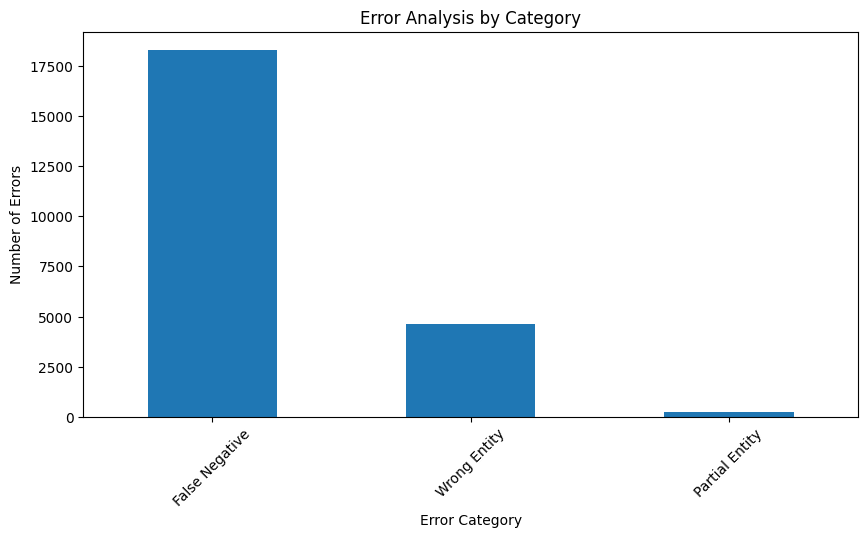

In [257]:
error_summary.plot(
    x="Error Category",
    y="Count",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Error Analysis by Category")
plt.xlabel("Error Category")
plt.ylabel("Number of Errors")
plt.xticks(rotation=45)
plt.show()

In [258]:
false_positive_cases = error_df[
    error_df["Error Category"] == "False Positive"
]

false_positive_cases[
    ["Text", "Actual", "Predicted", "Error Category"]
].head(20)

,Text,Actual,Predicted,Error Category


In [259]:
false_negative_cases = error_df[
    error_df["Error Category"] == "False Negative"
]

false_negative_cases[
    ["Text", "Actual", "Predicted", "Error Category"]
].head(20)

,Text,Actual,Predicted,Error Category
0,we are hiring a business analyst at deloitte i...,power bi,None,False Negative
1,we are hiring a business analyst at deloitte i...,jira,None,False Negative
2,we are hiring a business analyst at deloitte i...,statistics,None,False Negative
3,we are hiring a business analyst at deloitte i...,sql,None,False Negative
4,we are hiring a business analyst at persistent...,excel,None,False Negative
5,we are hiring a business analyst at persistent...,statistics,None,False Negative
6,we are hiring a business analyst at persistent...,power bi,None,False Negative
7,we are hiring a business analyst at persistent...,tableau,None,False Negative
8,we are hiring a business analyst at persistent...,sql,None,False Negative
9,we are hiring a machine learning engineer at d...,tensorflow,None,False Negative


In [260]:
# Create Error Analysis DataFrame

error_data = []

for text, actual, predicted in zip(
    df["clean_description"],
    df["true_skills"],
    df["extracted_skills"]
):
    
    actual = set(actual)
    predicted = set(predicted)

    if actual == predicted:
        error_category = "Correct"
    elif predicted - actual and not actual - predicted:
        error_category = "False Positive"
    elif actual - predicted and not predicted - actual:
        error_category = "False Negative"
    elif actual - predicted and predicted - actual:
        error_category = "Partial Entity"
    else:
        error_category = "Unknown Skill"

    error_data.append({
        "Text": text,
        "Actual": actual,
        "Predicted": predicted,
        "Error Category": error_category
    })

error_df = pd.DataFrame(error_data)

In [261]:
partial_cases = error_df[error_df["Error Category"] == "Partial Entity"]
partial_cases[["Text", "Actual", "Predicted", "Error Category"]].head(20)

,Text,Actual,Predicted,Error Category
0,we are hiring a business analyst at deloitte i...,"{power bi, jira, statistics, sql}","{SQL, Power BI}",Partial Entity
1,we are hiring a business analyst at persistent...,"{excel, statistics, power bi, tableau, sql}","{Power BI, Excel, SQL, Tableau}",Partial Entity
2,we are hiring a machine learning engineer at d...,"{tensorflow, python, aws, sql, machine learnin...","{AWS, Scikit-learn, TensorFlow, SQL, Python}",Partial Entity
3,we are hiring a python developer at wipro in r...,"{rest api, git, docker, fastapi, python, django}","{Django, Docker, REST API, Python}",Partial Entity
4,we are hiring a software engineer at capgemini...,{c++ | docker | rest api | sql | agile | java},"{Docker, REST API, SQL, Java}",Partial Entity
5,we are hiring a business analyst at persistent...,"{excel, jira, power bi, sql, tableau, statistics}","{Power BI, Excel, SQL, Tableau}",Partial Entity
6,we are hiring a nlp engineer at ibm in bengalu...,"{transformers, python, bert, nlp, machine lear...","{Transformers, Python, BERT}",Partial Entity
7,we are hiring a java developer at siemens in r...,"{rest api, git, docker, java, sql, spring boot...","{Docker, Git, REST API, Java}",Partial Entity
8,we are hiring a business analyst at tcs in del...,"{power bi, sql, tableau, statistics}","{Power BI, SQL, Tableau}",Partial Entity
9,we are hiring a python developer at siemens in...,"{rest api, docker, fastapi, python, flask, dja...","{Docker, Flask, Django, SQL, FastAPI, Python}",Partial Entity


In [262]:
synonym_cases = error_df[
    error_df["Error Category"] == "Synonym Problem"
]

synonym_cases[
    ["Text", "Actual", "Predicted", "Error Category"]
].head(20)

,Text,Actual,Predicted,Error Category


In [263]:
final_error_table = error_df[
    [
        "Text",
        "Actual",
        "Predicted",
        "Error Category"
    ]
].copy()

final_error_table.head(30)

,Text,Actual,Predicted,Error Category
0,we are hiring a business analyst at deloitte i...,"{power bi, jira, statistics, sql}","{SQL, Power BI}",Partial Entity
1,we are hiring a business analyst at persistent...,"{excel, statistics, power bi, tableau, sql}","{Power BI, Excel, SQL, Tableau}",Partial Entity
2,we are hiring a machine learning engineer at d...,"{tensorflow, python, aws, sql, machine learnin...","{AWS, Scikit-learn, TensorFlow, SQL, Python}",Partial Entity
3,we are hiring a python developer at wipro in r...,"{rest api, git, docker, fastapi, python, django}","{Django, Docker, REST API, Python}",Partial Entity
4,we are hiring a software engineer at capgemini...,{c++ | docker | rest api | sql | agile | java},"{Docker, REST API, SQL, Java}",Partial Entity
5,we are hiring a business analyst at persistent...,"{excel, jira, power bi, sql, tableau, statistics}","{Power BI, Excel, SQL, Tableau}",Partial Entity
6,we are hiring a nlp engineer at ibm in bengalu...,"{transformers, python, bert, nlp, machine lear...","{Transformers, Python, BERT}",Partial Entity
7,we are hiring a java developer at siemens in r...,"{rest api, git, docker, java, sql, spring boot...","{Docker, Git, REST API, Java}",Partial Entity
8,we are hiring a business analyst at tcs in del...,"{power bi, sql, tableau, statistics}","{Power BI, SQL, Tableau}",Partial Entity
9,we are hiring a python developer at siemens in...,"{rest api, docker, fastapi, python, flask, dja...","{Docker, Flask, Django, SQL, FastAPI, Python}",Partial Entity


Error Analysis was performed by comparing the skills extracted by the selected NLP approach against the reference skills generated from the required_skills field using the project skill taxonomy.

# Skill Normalization 

In [264]:
skill_normalization = {
    "python3": "Python",
    "python 3": "Python",
    "python programming": "Python",
    
    "powerbi": "Power BI",
    "power-bi": "Power BI",
    
    "machinelearning": "Machine Learning",
    "machine learning": "Machine Learning",
    
    "natural language processing": "NLP",
    "natural-language-processing": "NLP",
    
    "artificial intelligence": "AI",
    
    "postgres": "PostgreSQL",
    "postgre sql": "PostgreSQL",
    
    "scikit learn": "Scikit-learn",
    "scikit learn": "Scikit-learn",
    
    "tensorflow": "TensorFlow",
    "pytorch": "PyTorch"
}

In [265]:
def normalize_skill(skill):
    skill = str(skill).strip().lower()
    if skill in skill_normalization:
        return skill_normalization[skill]
    return skill.title()

In [266]:
test_skills = [
    "Python",
    "Python3",
    "Python 3",
    "Python programming",
    "PowerBI",
    "Power BI",
    "Power-BI"]
for skill in test_skills:
    print(skill, "→", normalize_skill(skill))

Python → Python
Python3 → Python
Python 3 → Python
Python programming → Python
PowerBI → Power BI
Power BI → Power Bi
Power-BI → Power BI


In [267]:
def normalize_skill(skill):
    
    skill = str(skill).strip().lower()
    
    if skill in skill_normalization:
        return skill_normalization[skill]
    
    standard_names = {
        "python": "Python",
        "power bi": "Power BI",
        "aws": "AWS",
        "sql": "SQL",
        "nlp": "NLP",
        "ai": "AI",
        "docker": "Docker",
        "kubernetes": "Kubernetes",
        "pandas": "Pandas",
        "numpy": "NumPy"
    }
    
    if skill in standard_names:
        return standard_names[skill]
    
    return skill.title()

In [268]:
for skill in test_skills:
    print(skill, "→", normalize_skill(skill))

Python → Python
Python3 → Python
Python 3 → Python
Python programming → Python
PowerBI → Power BI
Power BI → Power BI
Power-BI → Power BI


In [269]:
df["normalized_skills"] = df["required_skills"].apply(lambda x: [
        normalize_skill(skill)
        for skill in str(x).split(",")])

In [270]:
df[["required_skills", "normalized_skills"]].head(10)

,required_skills,normalized_skills
0,"SQL, JIRA, Power BI, Statistics","[SQL, Jira, Power BI, Statistics]"
1,"Tableau, Power BI, Excel, Statistics, SQL","[Tableau, Power BI, Excel, Statistics, SQL]"
2,"Python, Scikit-learn, TensorFlow, Machine Lear...","[Python, Scikit-Learn, TensorFlow, Machine Lea..."
3,"Python, REST API, Git, Docker, FastAPI, Django","[Python, Rest Api, Git, Docker, Fastapi, Django]"
4,C++ | Docker | REST API | SQL | Agile | Java,[C++ | Docker | Rest Api | Sql | Agile | Java]
5,"Tableau, Statistics, Power BI, Excel, JIRA, SQL","[Tableau, Statistics, Power BI, Excel, Jira, SQL]"
6,"NLP, BERT, Transformers, Machine Learning, Python","[NLP, Bert, Transformers, Machine Learning, Py..."
7,"Git, SQL, REST API, Docker, Java, Spring Boot,...","[Git, SQL, Rest Api, Docker, Java, Spring Boot..."
8,"Statistics, SQL, Tableau, Power BI","[Statistics, SQL, Tableau, Power BI]"
9,"Django, Python, Docker, SQL, FastAPI, Flask, R...","[Django, Python, Docker, SQL, Fastapi, Flask, ..."


In [271]:
def remove_duplicate_skills(skills):
    return sorted(set(skills))

In [272]:
df["normalized_skills"] = df["normalized_skills"].apply(remove_duplicate_skills)

In [273]:
df[["required_skills", "normalized_skills"]].head(10)

,required_skills,normalized_skills
0,"SQL, JIRA, Power BI, Statistics","[Jira, Power BI, SQL, Statistics]"
1,"Tableau, Power BI, Excel, Statistics, SQL","[Excel, Power BI, SQL, Statistics, Tableau]"
2,"Python, Scikit-learn, TensorFlow, Machine Lear...","[AWS, Machine Learning, Python, SQL, Scikit-Le..."
3,"Python, REST API, Git, Docker, FastAPI, Django","[Django, Docker, Fastapi, Git, Python, Rest Api]"
4,C++ | Docker | REST API | SQL | Agile | Java,[C++ | Docker | Rest Api | Sql | Agile | Java]
5,"Tableau, Statistics, Power BI, Excel, JIRA, SQL","[Excel, Jira, Power BI, SQL, Statistics, Tableau]"
6,"NLP, BERT, Transformers, Machine Learning, Python","[Bert, Machine Learning, NLP, Python, Transfor..."
7,"Git, SQL, REST API, Docker, Java, Spring Boot,...","[Docker, Git, Hibernate, Java, Microservices, ..."
8,"Statistics, SQL, Tableau, Power BI","[Power BI, SQL, Statistics, Tableau]"
9,"Django, Python, Docker, SQL, FastAPI, Flask, R...","[Django, Docker, Fastapi, Flask, Python, Rest ..."


In [274]:
from collections import Counter

skill_counts = Counter()

for skills in df["normalized_skills"]:
    skill_counts.update(skills)

skill_counts.most_common(15)

[('SQL', 2187),
 ('Python', 1812),
 ('Docker', 1394),
 ('Git', 1223),
 ('Machine Learning', 828),
 ('AWS', 813),
 ('Rest Api', 811),
 ('TensorFlow', 622),
 ('Power BI', 601),
 ('Statistics', 590),
 ('Excel', 589),
 ('Etl', 581),
 ('Scikit-Learn', 423),
 ('Azure', 423),
 ('Java', 418)]

In [275]:
# ==============================
# FINAL MODEL 1
# TF-IDF + Logistic Regression
# ==============================

X = training_df["text"]
y = training_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2)
    )),
    
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("TF-IDF + Logistic Regression")
print("--------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

TF-IDF + Logistic Regression
--------------------------------
Accuracy: 0.21428571428571427

Classification Report:
                      precision    recall  f1-score   support

            BIG_DATA       0.00      0.00      0.00         1
             BI_TOOL       0.00      0.00      0.00         1
      CLOUD_PLATFORM       0.00      0.00      0.00         1
            DATABASE       0.00      0.00      0.00         2
        DATA_LIBRARY       0.00      0.00      0.00         1
         DEVOPS_TOOL       0.00      0.00      0.00         1
        ML_FRAMEWORK       0.00      0.00      0.00         1
PROGRAMMING_LANGUAGE       0.00      0.00      0.00         1
               SKILL       0.21      1.00      0.35         3
      WEB_TECHNOLOGY       0.00      0.00      0.00         2

            accuracy                           0.21        14
           macro avg       0.02      0.10      0.04        14
        weighted avg       0.05      0.21      0.08        14



In [276]:
test_skills = [
    "Python",
    "AWS",
    "PostgreSQL",
    "Power BI",
    "TensorFlow",
    "Docker"
]

predictions = model.predict(test_skills)

for skill, prediction in zip(test_skills, predictions):
    print(skill, "→", prediction)

Python → SKILL
AWS → SKILL
PostgreSQL → DATABASE
Power BI → SKILL
TensorFlow → SKILL
Docker → DEVOPS_TOOL


In [277]:
import joblib

joblib.dump(model, "skill_category_model.pkl")

print("ML model saved successfully.")

ML model saved successfully.


In [278]:
# ==============================
# FINAL MODEL 2
# DistilBERT NER
# ==============================

from transformers import pipeline

transformer_ner = pipeline(
    "token-classification",
    model="dslim/distilbert-NER",
    aggregation_strategy="simple",
    device=-1)
print("DistilBERT NER model loaded successfully.")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DistilBERT NER model loaded successfully.


In [279]:
text = df["clean_description"].iloc[0]
entities = transformer_ner(text)
for entity in entities:
    print(
        entity["word"],
        "→",
        entity["entity_group"],
        round(float(entity["score"]), 3)
    )

del → ORG 0.943
##oit → ORG 0.979
##te → ORG 0.984


In [280]:
def transformer_entities(text):
    entities = transformer_ner(str(text))
    return [
        (entity["word"],
        entity["entity_group"],
        round(float(entity["score"]), 3))
        for entity in entities]

In [281]:
df["transformer_entities"] = df["clean_description"].apply(transformer_entities)

In [282]:
df[["job_description", "transformer_entities"]].head(10)

,job_description,transformer_entities
0,We are hiring a Business Analyst at Deloitte i...,"[(del, ORG, 0.943), (##oit, ORG, 0.979), (##te..."
1,We are hiring a Business Analyst at Persistent...,"[(##dia, LOC, 0.624)]"
2,We are hiring a Machine Learning Engineer at D...,"[(del, ORG, 0.908), (##oit, ORG, 0.96), (##te,..."
3,We are hiring a Python Developer at Wipro in R...,"[(##ip, ORG, 0.915), (##ro, ORG, 0.927), (##di..."
4,We are hiring a Software Engineer at Capgemini...,"[(cap, ORG, 0.58), (##ge, ORG, 0.914), (##mini..."
5,We are hiring a Business Analyst at Persistent...,"[(ben, LOC, 0.609), (##gal, LOC, 0.875), (##ur..."
6,We are hiring a NLP Engineer at IBM in Bengalu...,"[(i, ORG, 0.592), (##m, ORG, 0.745), (ben, LOC..."
7,We are hiring a Java Developer at Siemens in R...,"[(##dia, LOC, 0.52)]"
8,We are hiring a Business Analyst at TCS in Del...,"[(del, LOC, 0.774), (##hi, LOC, 0.935)]"
9,We are hiring a Python Developer at Siemens in...,"[(##ens, LOC, 0.404), (##g, LOC, 0.487), (##pu..."
